In [22]:
from pathlib import Path
Path(".").resolve()

import sys
sys.executable
...


Ellipsis

In [2]:
import sys
sys.executable


'c:\\Users\\EM2024006937\\Documents\\Documentos\\Pessoais\\FGV\\Dissertação\\Dissertação_Bitcoin_ML\\.venv\\Scripts\\python.exe'

In [3]:
import numpy, pandas, matplotlib
print(numpy.__version__, pandas.__version__)


2.3.5 2.3.3


# Capítulo 6 — Machine Learning (Volatility Risk Premium do Bitcoin)

**Dissertação:** Volatility Risk Premium in Bitcoin: Structure, Regimes and Machine-Learning Forecasting  
**Notebook:** `Cap6_ML.ipynb`

## Objetivo do Capítulo
Este notebook implementa o pipeline completo de *Machine Learning* utilizado no Capítulo 6 da dissertação, com foco na previsão do prêmio de risco de volatilidade do Bitcoin (BVRP) do Bitcoin.

O pipeline contempla:
1. carregamento e validação do dataset final;
2. definição do alvo preditivo (BVRP);
3. separação temporal da amostra (train / validation / test);
4. engenharia de variáveis;
5. estimação de modelos preditivos;
6. avaliação estatística e econômica dos resultados.

## Reprodutibilidade
- Todas as decisões de caminhos, parâmetros e datas são centralizadas em um bloco de configuração.
- As divisões de amostra são **temporais**, evitando *look-ahead bias*.
- Todas as figuras e tabelas são salvas automaticamente para uso direto no texto da dissertação.


In [40]:
# ============================================================
# 0.1) AMBIENTE, PATHS E VERSÕES
# ============================================================

from pathlib import Path
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib

CWD = Path.cwd().resolve()

print("CWD         :", CWD)
print("PYTHON EXE  :", sys.executable)
print("Python ver  :", sys.version.split()[0], "|", platform.platform())
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", matplotlib.__version__)


CWD         : C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML
PYTHON EXE  : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\.venv\Scripts\python.exe
Python ver  : 3.13.6 | Windows-11-10.0.26200-SP0
NumPy       : 2.3.5
Pandas      : 2.3.3
Matplotlib  : 3.10.7


In [30]:
# ============================================================
# 0.2) CONFIGURAÇÃO GERAL E IMPORTS (CAP. 6 - ML)
# ============================================================

from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Descobrir raiz do projeto (funciona se o notebook estiver em /code)
# ------------------------------------------------------------
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "code" else CWD

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "cap6_ml"

@dataclass
class Config:
    project_root: Path = PROJECT_ROOT
    data_dir: Path = DATA_DIR
    outputs_dir: Path = OUTPUTS_DIR

    # subpastas padronizadas do Cap. 6
    figures_dir: Path = OUTPUTS_DIR / "figures"
    tables_dir: Path  = OUTPUTS_DIR / "tables"
    metrics_dir: Path = OUTPUTS_DIR / "metrics"
    models_dir: Path  = OUTPUTS_DIR / "models"

    # dataset final padronizado (Cap. 6): BVRP
    dataset_filename: str = "bvrp_with_targets.csv"

    # colunas principais
    date_col: str = "date"

    # NOMENCLATURA OFICIAL (Cap. 6): BVRP
    target_reg: str = "bvrp_30d"

    # compatibilidade com datasets antigos
    legacy_target_reg: str = "vrp_30d"

    # reprodutibilidade
    seed: int = 42

cfg = Config()

# criação de diretórios de saída (robusto)
cfg.outputs_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)
cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.metrics_dir.mkdir(parents=True, exist_ok=True)
cfg.models_dir.mkdir(parents=True, exist_ok=True)

# seed global
np.random.seed(cfg.seed)

print("CWD         :", CWD.resolve())
print("PYTHON EXE  :", sys.executable)
print("Project root:", cfg.project_root.resolve())
print("Data dir    :", cfg.data_dir.resolve())
print("Outputs dir :", cfg.outputs_dir.resolve())
print("Dataset path:", (cfg.data_dir / cfg.dataset_filename).resolve())
print("Dataset exists?", (cfg.data_dir / cfg.dataset_filename).exists())


CWD         : C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML
PYTHON EXE  : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\.venv\Scripts\python.exe
Project root: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML
Data dir    : C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\data
Outputs dir : C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml
Dataset path: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\data\bvrp_with_targets.csv
Dataset exists? True


## Convenções de Saída — Capítulo 6

- **Figuras:** `outputs/cap6_ml/figures/`
- **Tabelas:** `outputs/cap6_ml/tables/`
- **Métricas:** `outputs/cap6_ml/metrics/`
- **Modelos:** `outputs/cap6_ml/models/`

Todas as figuras e tabelas geradas neste notebook são salvas automaticamente e utilizadas diretamente no texto do Capítulo 6 da dissertação.


# 1. Dados e Alvo Preditivo

Esta seção descreve:
1. o carregamento do dataset final utilizado na análise;
2. as verificações básicas de integridade dos dados;
3. a definição do alvo preditivo (VRP);
4. a separação temporal da amostra em treino, validação e teste.

**Princípio fundamental:** nenhuma informação futura é utilizada em qualquer etapa do pipeline.


## 1.1 Este capítulo investiga o Prêmio de Risco de Volatilidade do Bitcoin sob duas
perspectivas complementares:

(i) análise contemporânea e estrutural do BVRP;
(ii) formulação do problema de previsão fora da amostra via machine learning.


## 1.2 Carregamento do dataset final (BVRP contemporâneo)


Nesta etapa, carregamos o dataset consolidado utilizado no Capítulo 6.

Requisitos mínimos do dataset:
- conter uma coluna de data (`date`);
- conter o alvo preditivo contínuo (`vrp_30d`);
- estar alinhado em frequência temporal consistente (ex.: diário);
- permitir ordenação temporal para evitar *look-ahead bias*.

O arquivo utilizado é definido no bloco de configuração (`cfg.dataset_filename`) e deve estar localizado em `../data/`.


In [31]:
# ============================================================
# 1.2 CARREGAMENTO DO DATASET FINAL (PADRONIZAÇÃO BVRP)
# ============================================================

def load_dataset(cfg: Config) -> pd.DataFrame:
    """
    Carrega o dataset final do Capítulo 6 e garante:
    - leitura correta (CSV ou Parquet);
    - conversão da coluna de data;
    - ordenação temporal;
    - ausência de datas inválidas ou duplicadas;
    - padronização da nomenclatura do alvo para BVRP (bvrp_30d).

    Retorna
    -------
    pd.DataFrame
        Dataset pronto para análise e modelagem.
    """
    path = cfg.data_dir / cfg.dataset_filename

    if not path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {path.resolve()}")

    # --------------------------------------------------------
    # leitura conforme extensão
    # --------------------------------------------------------
    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
    elif path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    else:
        raise ValueError(f"Formato de arquivo não suportado: {path.suffix}")

    # --------------------------------------------------------
    # checagem da coluna de data
    # --------------------------------------------------------
    if cfg.date_col not in df.columns:
        raise KeyError(
            f"Coluna de data '{cfg.date_col}' não encontrada. "
            f"Colunas disponíveis: {list(df.columns)}"
        )

    # conversão e ordenação temporal
    df[cfg.date_col] = pd.to_datetime(df[cfg.date_col], errors="coerce")

    if df[cfg.date_col].isna().any():
        n_na = df[cfg.date_col].isna().sum()
        raise ValueError(f"Existem {n_na} datas inválidas (NaT) após conversão.")

    if df[cfg.date_col].duplicated().any():
        dup = df.loc[df[cfg.date_col].duplicated(), cfg.date_col].head(5)
        raise ValueError(f"Datas duplicadas encontradas. Exemplos:\n{dup}")

    df = df.sort_values(cfg.date_col).reset_index(drop=True)

    # --------------------------------------------------------
    # padronização do target: VRP -> BVRP
    # --------------------------------------------------------
    if cfg.target_reg not in df.columns:
        if cfg.legacy_target_reg in df.columns:
            print(
                f"⚠️ '{cfg.target_reg}' não encontrado. "
                f"Renomeando '{cfg.legacy_target_reg}' -> '{cfg.target_reg}'..."
            )
            df = df.rename(columns={cfg.legacy_target_reg: cfg.target_reg})
        else:
            raise KeyError(
                f"Não encontrei nem '{cfg.target_reg}' nem '{cfg.legacy_target_reg}'. "
                f"Colunas disponíveis: {list(df.columns)}"
            )

    return df


# ------------------------------------------------------------
# carregar dataset
# ------------------------------------------------------------
df = load_dataset(cfg)

print("Dimensão do dataset:", df.shape)
display(df.head())


Dimensão do dataset: (623, 9)


,date,close,ret,rv_30d,iv_30d,bvrp_30d,ret_fut_1d,ret_fut_5d,ret_fut_20d
0,2023-02-27,23492.09,-0.002668,52.180368,50.44,-1.740368,-0.014921,0.198934,0.225821
1,2023-02-28,23141.57,-0.015033,51.292610,50.37,-0.922610,0.229507,0.217290,0.220473
2,2023-04-01,28452.73,0.206614,87.224138,58.17,-29.054138,-0.009871,-0.014723,-0.041820
3,2023-04-02,28171.87,-0.009920,87.403177,60.28,-27.123177,-0.013200,-0.009426,-0.012602
4,2023-04-03,27800.00,-0.013288,87.380827,61.83,-25.550827,0.013146,0.004978,-0.007532


## 1.3 Validações básicas e inspeção do BVRP contemporâneo


Com o dataset carregado, realizamos checagens mínimas de integridade antes de
prosseguir para a engenharia de variáveis e modelagem:

1. verificação de duplicidade temporal;
2. inspeção do intervalo amostral;
3. estatísticas descritivas do alvo **BVRP 30 dias** (`bvrp_30d`);
4. avaliação de valores ausentes nas variáveis principais.

Essas etapas garantem que o pipeline de *machine learning* opere sem
inconsistências ou vazamento de informação.


In [32]:
# ============================================================
# 1.3 VALIDAÇÕES BÁSICAS DO DATASET (BVRP)
# ============================================================

print("Colunas disponíveis no dataset:")
print(list(df.columns))

# ------------------------------------------------------------
# 1) checagem de duplicidade temporal
# ------------------------------------------------------------
if df[cfg.date_col].duplicated().any():
    dup = df.loc[df[cfg.date_col].duplicated(), cfg.date_col].head(10)
    raise ValueError(f"Datas duplicadas encontradas. Exemplos:\n{dup}")

print("✔️ Nenhuma data duplicada encontrada.")

# ------------------------------------------------------------
# 2) intervalo temporal da amostra
# ------------------------------------------------------------
start_date = df[cfg.date_col].min()
end_date   = df[cfg.date_col].max()

print(f"Período da amostra: {start_date.date()} → {end_date.date()}")
print(f"Número de observações: {len(df)}")
print(f"Número de variáveis: {df.shape[1]}")

# ------------------------------------------------------------
# 3) estatísticas descritivas do alvo (BVRP)
# ------------------------------------------------------------
print(f"\nResumo estatístico do BVRP ({cfg.target_reg}):")

bvrp_stats = (
    df[cfg.target_reg]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame()
    .T
)

display(bvrp_stats)

# salvar estatísticas para uso no texto / LaTeX
stats_path = cfg.tables_dir / "bvrp_descriptive_stats_cap6.csv"
bvrp_stats.to_csv(stats_path, index=False)

print("💾 Estatísticas descritivas salvas em:", stats_path)

# ------------------------------------------------------------
# 4) valores ausentes (variáveis principais)
# ------------------------------------------------------------
missing_main = (
    df[[cfg.date_col, cfg.target_reg]]
    .isna()
    .mean()
    .to_frame("missing_ratio")
)

print("\nProporção de valores ausentes (variáveis principais):")
display(missing_main)


Colunas disponíveis no dataset:
['date', 'close', 'ret', 'rv_30d', 'iv_30d', 'bvrp_30d', 'ret_fut_1d', 'ret_fut_5d', 'ret_fut_20d']
✔️ Nenhuma data duplicada encontrada.
Período da amostra: 2023-02-27 → 2024-12-11
Número de observações: 623
Número de variáveis: 9

Resumo estatístico do BVRP (bvrp_30d):


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
bvrp_30d,623.0,5.355343,11.587143,-32.405652,-30.343742,-17.741991,0.297066,6.826466,12.42792,20.445539,25.64981,28.355131


💾 Estatísticas descritivas salvas em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\bvrp_descriptive_stats_cap6.csv

Proporção de valores ausentes (variáveis principais):


,missing_ratio
date,0.0
bvrp_30d,0.0


In [7]:
df.to_csv(cfg.data_dir / "bvrp_with_targets.csv", index=False)
print("Salvo dataset padronizado:", (cfg.data_dir / "bvrp_with_targets.csv").resolve())


Salvo dataset padronizado: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\data\bvrp_with_targets.csv


## 1.4 Dinâmica temporal do Prêmio de Risco de Volatilidade (BVRP)

Antes da modelagem, analisamos a dinâmica temporal do prêmio de risco de
volatilidade do Bitcoin.

O objetivo desta visualização é:
- identificar regimes e períodos de estresse;
- avaliar assimetrias e mudanças de nível ao longo do tempo;
- fornecer motivação econômica para o uso de modelos não lineares no Capítulo 6.

O gráfico gerado nesta seção será utilizado diretamente na versão final da dissertação.


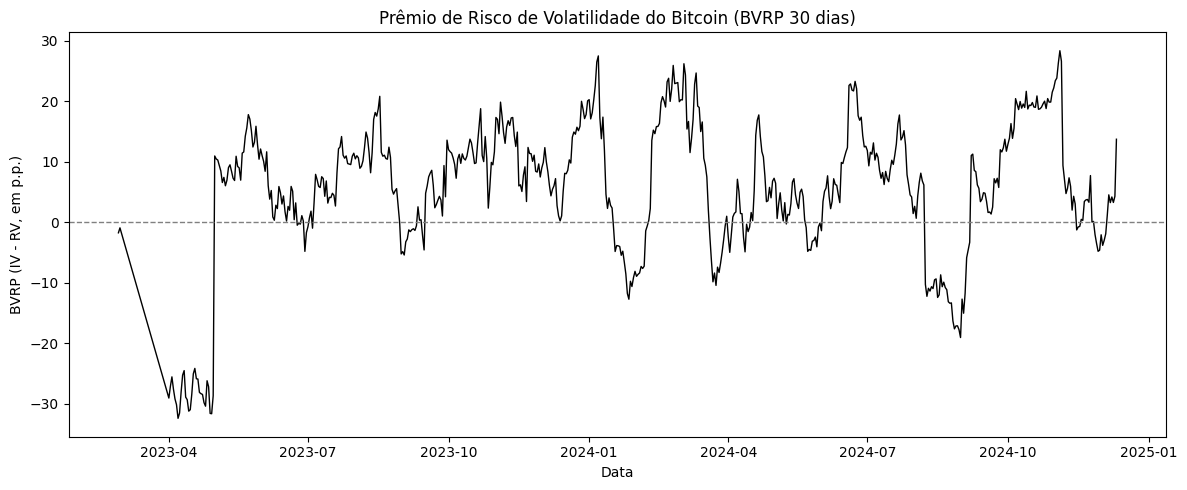

Figura salva em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\figures\bvrp_30d_timeseries.png


In [ ]:
# ============================================================
# 1.4 GRÁFICO DO VRP AO LONGO DO TEMPO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df[cfg.date_col],
    df[cfg.target_reg],
    color="black",
    linewidth=1
)

ax.axhline(0, linestyle="--", linewidth=1, color="gray")

ax.set_title("Prêmio de Risco de Volatilidade do Bitcoin (BVRP 30 dias)")
ax.set_xlabel("Data")
ax.set_ylabel("BVRP (IV - RV, em p.p.)")

plt.tight_layout()

# salvar figura para o Capítulo 6
fig_path = cfg.outputs_dir / "figures" / "bvrp_30d_timeseries.png"

plt.savefig(fig_path, dpi=300)

plt.show()

print(f"Figura salva em: {fig_path}")


A Figura X apresenta a dinâmica temporal do prêmio de risco de volatilidade do Bitcoin (BVRP) ao longo da amostra, evidenciando períodos de forte assimetria e mudanças de regime, o que motiva o uso de modelos não lineares no Capítulo 6.

In [9]:
old_path = cfg.outputs_dir / "figures" / "vrp_30d_timeseries.png"
if old_path.exists():
    old_path.unlink()
    print("Arquivo antigo removido:", old_path)
else:
    print("Arquivo antigo não encontrado (ok).")


Arquivo antigo não encontrado (ok).


## 1.5 Divisão temporal da amostra (referência estrutural)


Como trabalhamos com série temporal, a divisão da amostra precisa respeitar a ordem
cronológica para evitar *look-ahead bias*.

Nesta etapa:
- indexamos o dataset por data;
- criamos os subconjuntos `train`, `val` e `test` com cortes temporais;
- verificamos se nenhum conjunto ficou vazio.

**Regra:** nada de embaralhar (*shuffle = False*).


In [34]:
# ============================================================
# 1.5 TIME SPLIT ROBUSTO (POR PROPORÇÃO, SEM SHUFFLE)
# ============================================================

def time_split_by_ratio(df: pd.DataFrame, cfg: Config, train_ratio=0.70, val_ratio=0.15):
    d = df.copy().sort_values(cfg.date_col).set_index(cfg.date_col)

    n = len(d)
    if n < 50:
        raise ValueError(f"Dataset muito pequeno para split robusto (n={n}).")

    train_end_idx = int(n * train_ratio)
    val_end_idx   = int(n * (train_ratio + val_ratio))

    train = d.iloc[:train_end_idx].copy()
    val   = d.iloc[train_end_idx:val_end_idx].copy()
    test  = d.iloc[val_end_idx:].copy()

    if len(train) == 0 or len(val) == 0 or len(test) == 0:
        raise ValueError(
            f"Split vazio. sizes: train={len(train)}, val={len(val)}, test={len(test)}. "
            "Ajuste ratios."
        )

    return {"train": train, "val": val, "test": test}

splits = time_split_by_ratio(df, cfg, train_ratio=0.70, val_ratio=0.15)

for k, d in splits.items():
    print(f"{k.upper():5s} | n={len(d):4d} | {d.index.min().date()} -> {d.index.max().date()}")

# sanity: target presente em todos
for k, d in splits.items():
    if cfg.target_reg not in d.columns:
        raise KeyError(f"Target '{cfg.target_reg}' não existe no split {k}. Colunas: {list(d.columns)}")

print("\n✔️ Split temporal por proporção concluído (sem shuffle) e target BVRP presente.")


TRAIN | n= 436 | 2023-02-27 -> 2024-06-07
VAL   | n=  93 | 2024-06-08 -> 2024-09-08
TEST  | n=  94 | 2024-09-09 -> 2024-12-11

✔️ Split temporal por proporção concluído (sem shuffle) e target BVRP presente.


## 1.6 Registro dos cortes temporais da amostra


Para garantir reprodutibilidade e facilitar a escrita do Capítulo 6, registramos as
datas de corte e o tamanho de cada subconjunto (train/val/test), exportando uma
tabela-resumo para `outputs/cap6_ml/tables/`.

Essas informações serão referenciadas explicitamente no texto ao descrever o
desenho experimental e a avaliação fora da amostra.


In [35]:
# ============================================================
# 1.6 SALVAR RESUMO DO SPLIT (TABELA + JSON) — FIX JSON DATES
# ============================================================

import json

split_summary = pd.DataFrame({
    "set": ["train", "val", "test"],
    "n_obs": [len(splits["train"]), len(splits["val"]), len(splits["test"])],
    "start_date": [
        splits["train"].index.min().date(),
        splits["val"].index.min().date(),
        splits["test"].index.min().date(),
    ],
    "end_date": [
        splits["train"].index.max().date(),
        splits["val"].index.max().date(),
        splits["test"].index.max().date(),
    ],
})

display(split_summary)

# salvar CSV
csv_path = cfg.outputs_dir / "tables" / "split_summary_cap6.csv"
split_summary.to_csv(csv_path, index=False)

# salvar JSON (converter date -> string ISO)
json_path = cfg.outputs_dir / "metrics" / "split_summary_cap6.json"
records = split_summary.copy()
records["start_date"] = records["start_date"].astype(str)
records["end_date"]   = records["end_date"].astype(str)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(records.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("Tabela salva em:", csv_path)
print("JSON salvo em  :", json_path)

# garantir a pasta correta
(cfg.outputs_dir / "metrics").mkdir(exist_ok=True)
print("Metrics dir:", (cfg.outputs_dir / "metrics").resolve())

import json

json_path = cfg.outputs_dir / "metrics" / "split_summary_cap6.json"

records = split_summary.copy()
records["start_date"] = records["start_date"].astype(str)
records["end_date"]   = records["end_date"].astype(str)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(records.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("✅ JSON re-salvo em:", json_path.resolve())



,set,n_obs,start_date,end_date
0,train,436,2023-02-27,2024-06-07
1,val,93,2024-06-08,2024-09-08
2,test,94,2024-09-09,2024-12-11


Tabela salva em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\split_summary_cap6.csv
JSON salvo em  : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\split_summary_cap6.json
Metrics dir: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics
✅ JSON re-salvo em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\split_summary_cap6.json


## 1.7 Reformulação do problema preditivo: alvo futuro do BVRP (t+1)


Nesta subseção, redefinimos o alvo preditivo do problema de *machine learning*,
passando a considerar explicitamente um **horizonte temporal de previsão**.

Em vez de modelar o prêmio de risco de volatilidade contemporâneo, o objetivo
torna-se prever o valor observado **um dia à frente**, utilizando exclusivamente
informações disponíveis até o instante da previsão.

### Definição do novo alvo

O novo alvo preditivo é definido como:

\[
\text{BVRP}_{t+1} = \text{shift}\big(\text{BVRP}_{t}, -1\big)
\]

Na prática, isso implica deslocar a série do prêmio de risco de volatilidade em
uma unidade temporal para frente, de modo que cada observação em \( t \) esteja
associada ao valor observado em \( t+1 \).

### Motivação

A adoção de um alvo futuro é recomendada por três razões principais:

- **Evita predição trivial**  
  O BVRP apresenta elevada persistência temporal. Prever o valor contemporâneo
  pode inflar artificialmente o desempenho de modelos simples.

- **Coerência econômica**  
  Em aplicações reais, decisões de investimento e gestão de risco são tomadas
  com base em expectativas sobre o comportamento futuro do prêmio de risco.

- **Ausência de *look-ahead bias***  
  A construção do alvo por deslocamento temporal garante que nenhuma informação
  futura seja utilizada direta ou indiretamente no processo de estimação.

### Implicações para o pipeline

A redefinição do alvo implica que:

- o alvo preditivo passa a ser **BVRP futuro de 1 dia** (`bvrp_fut_1d`);
- a última observação da amostra é descartada, por não possuir valor futuro observável;
- a separação temporal da amostra (*train / validation / test*) é refeita após
  a criação do novo alvo;
- todas as transformações estatísticas e modelos subsequentes utilizam
  exclusivamente esse novo alvo.

A partir desta seção, **todas as análises de *machine learning*** no Capítulo 6
são conduzidas com base na previsão do **BVRP observado um dia à frente**.


## 1.7A — Opção A (diagnóstico) Opção A — Alvo contemporâneo (diagnóstico e coerência)

Nesta etapa, formulamos uma versão **contemporânea** do problema preditivo,
na qual o objetivo é modelar o prêmio de risco de volatilidade observado no mesmo instante \(t\).

### Definição do alvo (contemporâneo)

O alvo é definido como:

\[
y_t = \text{BVRP}_t
\]

Ou seja, o modelo utiliza apenas variáveis observadas em \(t\) para explicar o
prêmio de risco de volatilidade observado em \(t\).

### Propósito (por que manter)

Esta opção é mantida **apenas como diagnóstico e coerência metodológica**, pois:

- permite verificar a capacidade explicativa contemporânea das variáveis;
- ajuda a identificar persistência e facilidade de predição (potencial inflação de desempenho);
- serve como comparação conceitual antes de adotar o alvo com horizonte de previsão (Opção B).

### Observação importante

Os resultados desta opção **não são o foco central do capítulo**.
O experimento principal de previsão fora da amostra é conduzido com alvo futuro (Opção B),
no qual a variável-alvo corresponde a \(\text{BVRP}_{t+1}\).


In [46]:
# ============================================================
# 1.7A — Opção A (diagnóstico) OPÇÃO A (DIAGNÓSTICO): alvo contemporâneo = BVRP_t (sem shift)
# ============================================================

import json
import numpy as np
import pandas as pd

# ----------------------------
# 0) Garantias básicas
# ----------------------------
df_A = df.copy().sort_values(cfg.date_col).reset_index(drop=True)

# garantir target padronizado
if cfg.target_reg not in df_A.columns:
    if cfg.legacy_target_reg in df_A.columns:
        df_A = df_A.rename(columns={cfg.legacy_target_reg: cfg.target_reg})
    else:
        raise KeyError(f"Não encontrei target '{cfg.target_reg}' no df.")

print(f"Dataset (Opção A) p/ modelagem: {df_A.shape}")
print(f"Período: {df_A[cfg.date_col].min().date()} -> {df_A[cfg.date_col].max().date()}")
print(f"✅ Alvo contemporâneo (Opção A): {cfg.target_reg}")

# ----------------------------
# 1) Split temporal (mesma função)
# ----------------------------
splits_A = time_split_by_ratio(df_A, cfg, train_ratio=0.70, val_ratio=0.15)

for k, d in splits_A.items():
    print(f"{k.upper():5s} | n={len(d):4d} | {d.index.min().date()} -> {d.index.max().date()}")

# ----------------------------
# 2) Seleção de features (sem leakage) + X/y alinhados
# ----------------------------
leakage_prefixes = ["ret_fut_"]
leakage_cols_A = [c for c in df_A.columns if any(c.startswith(p) for p in leakage_prefixes)]

non_feature_cols_A = [cfg.date_col, cfg.target_reg] + leakage_cols_A
feature_cols_A = [c for c in df_A.columns if c not in non_feature_cols_A]

print("❌ Colunas removidas por leakage:", leakage_cols_A)
print("ℹ️ Colunas não-feature:", non_feature_cols_A)
print("✅ Features finais (Opção A):", feature_cols_A)

X_A = df_A.set_index(cfg.date_col)[feature_cols_A].copy()
y_A = df_A.set_index(cfg.date_col)[cfg.target_reg].copy()

X_train_A = X_A.loc[splits_A["train"].index]
X_val_A   = X_A.loc[splits_A["val"].index]
X_test_A  = X_A.loc[splits_A["test"].index]

y_train_A = y_A.loc[splits_A["train"].index]
y_val_A   = y_A.loc[splits_A["val"].index]
y_test_A  = y_A.loc[splits_A["test"].index]

print("Shapes finais (Opção A):")
print("X_train_A:", X_train_A.shape, "| y_train_A:", y_train_A.shape)
print("X_val_A  :", X_val_A.shape,   "| y_val_A  :", y_val_A.shape)
print("X_test_A :", X_test_A.shape,  "| y_test_A :", y_test_A.shape)

# ----------------------------
# 3) (Opcional) salvar split summary (A) com outro nome
# ----------------------------
split_summary_A = pd.DataFrame({
    "set": ["train", "val", "test"],
    "n_obs": [len(splits_A["train"]), len(splits_A["val"]), len(splits_A["test"])],
    "start_date": [
        splits_A["train"].index.min().date(),
        splits_A["val"].index.min().date(),
        splits_A["test"].index.min().date(),
    ],
    "end_date": [
        splits_A["train"].index.max().date(),
        splits_A["val"].index.max().date(),
        splits_A["test"].index.max().date(),
    ],
})

csv_path_A = cfg.outputs_dir / "tables" / "split_summary_cap6_optionA.csv"
split_summary_A.to_csv(csv_path_A, index=False)

json_path_A = cfg.outputs_dir / "metrics" / "split_summary_cap6_optionA.json"
records_A = split_summary_A.copy()
records_A["start_date"] = records_A["start_date"].astype(str)
records_A["end_date"]   = records_A["end_date"].astype(str)

(cfg.outputs_dir / "metrics").mkdir(parents=True, exist_ok=True)
with open(json_path_A, "w", encoding="utf-8") as f:
    json.dump(records_A.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("💾 Split summary (Opção A) CSV :", csv_path_A)
print("💾 Split summary (Opção A) JSON:", json_path_A)


Dataset (Opção A) p/ modelagem: (623, 10)
Período: 2023-02-27 -> 2024-12-11
✅ Alvo contemporâneo (Opção A): bvrp_30d
TRAIN | n= 436 | 2023-02-27 -> 2024-06-07
VAL   | n=  93 | 2024-06-08 -> 2024-09-08
TEST  | n=  94 | 2024-09-09 -> 2024-12-11
❌ Colunas removidas por leakage: ['ret_fut_1d', 'ret_fut_5d', 'ret_fut_20d']
ℹ️ Colunas não-feature: ['date', 'bvrp_30d', 'ret_fut_1d', 'ret_fut_5d', 'ret_fut_20d']
✅ Features finais (Opção A): ['close', 'ret', 'rv_30d', 'iv_30d', 'bvrp_fut_1d']
Shapes finais (Opção A):
X_train_A: (436, 5) | y_train_A: (436,)
X_val_A  : (93, 5) | y_val_A  : (93,)
X_test_A : (94, 5) | y_test_A : (94,)
💾 Split summary (Opção A) CSV : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\split_summary_cap6_optionA.csv
💾 Split summary (Opção A) JSON: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\split_summary_cap6_optionA.json


In [55]:
# ============================================================
# 1.7B — OPÇÃO B (RECOMENDADO)
# Alvo futuro: BVRP_{t+1} = shift(-1) + drop + re-split
# ============================================================

import json
import numpy as np
import pandas as pd

# ----------------------------
# 0) Garantias básicas
# ----------------------------
df_ml = df.copy().sort_values(cfg.date_col).reset_index(drop=True)

# garantir nomenclatura padronizada do target
if cfg.target_reg not in df_ml.columns:
    if cfg.legacy_target_reg in df_ml.columns:
        df_ml = df_ml.rename(columns={cfg.legacy_target_reg: cfg.target_reg})
    else:
        raise KeyError(f"Não encontrei target '{cfg.target_reg}' no dataset.")

# ----------------------------
# 1) Criar alvo futuro (t+1)
# ----------------------------
TARGET_FUT = "bvrp_fut_1d"
df_ml[TARGET_FUT] = df_ml[cfg.target_reg].shift(-1)

# remover última observação (sem alvo futuro observável)
df_ml = df_ml.dropna(subset=[TARGET_FUT]).copy()

print(f"Dataset p/ modelagem (com target futuro): {df_ml.shape}")
print(f"Período: {df_ml[cfg.date_col].min().date()} -> {df_ml[cfg.date_col].max().date()}")
print(f"✅ Novo alvo definido: {TARGET_FUT}")

# ----------------------------
# 2) Split temporal (após criação do alvo)
# ----------------------------
splits = time_split_by_ratio(df_ml, cfg, train_ratio=0.70, val_ratio=0.15)

for k, d in splits.items():
    print(f"{k.upper():5s} | n={len(d):4d} | {d.index.min().date()} -> {d.index.max().date()}")

# ----------------------------
# 3) Seleção de features (sem vazamento)
# ----------------------------
leakage_prefixes = ["ret_fut_"]
leakage_cols = [c for c in df_ml.columns if any(c.startswith(p) for p in leakage_prefixes)]

non_feature_cols = [
    cfg.date_col,
    cfg.target_reg,   # BVRP_t
    TARGET_FUT        # BVRP_{t+1}
] + leakage_cols

feature_cols = [c for c in df_ml.columns if c not in non_feature_cols]

print("❌ Colunas removidas por leakage:", leakage_cols)
print("ℹ️ Colunas não-feature:", non_feature_cols)
print("✅ Features finais:", feature_cols)

# ----------------------------
# 4) Construção de X e y (alinhados temporalmente)
# ----------------------------
X = df_ml.set_index(cfg.date_col)[feature_cols].copy()
y = df_ml.set_index(cfg.date_col)[TARGET_FUT].copy()

X_train = X.loc[splits["train"].index]
X_val   = X.loc[splits["val"].index]
X_test  = X.loc[splits["test"].index]

y_train = y.loc[splits["train"].index]
y_val   = y.loc[splits["val"].index]
y_test  = y.loc[splits["test"].index]

print("\nShapes finais:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

# ----------------------------
# 5) (Opcional) salvar dataset final de ML
# ----------------------------
ml_path = cfg.data_dir / "bvrp_ml_target_fut_1d.csv"
df_ml.to_csv(ml_path, index=False)
print("💾 Dataset de modelagem salvo em:", ml_path.resolve())

# ----------------------------
# 6) (Opcional) salvar resumo do split
# ----------------------------
split_summary = pd.DataFrame({
    "set": ["train", "val", "test"],
    "n_obs": [len(splits["train"]), len(splits["val"]), len(splits["test"])],
    "start_date": [
        splits["train"].index.min().date(),
        splits["val"].index.min().date(),
        splits["test"].index.min().date(),
    ],
    "end_date": [
        splits["train"].index.max().date(),
        splits["val"].index.max().date(),
        splits["test"].index.max().date(),
    ],
})

csv_path = cfg.outputs_dir / "tables" / "split_summary_cap6.csv"
json_path = cfg.outputs_dir / "metrics" / "split_summary_cap6.json"

split_summary.to_csv(csv_path, index=False)

records = split_summary.copy()
records["start_date"] = records["start_date"].astype(str)
records["end_date"]   = records["end_date"].astype(str)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(records.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("💾 Split summary CSV :", csv_path)
print("💾 Split summary JSON:", json_path)


Dataset p/ modelagem (com target futuro): (622, 10)
Período: 2023-02-27 -> 2024-12-10
✅ Novo alvo definido: bvrp_fut_1d
TRAIN | n= 435 | 2023-02-27 -> 2024-06-06
VAL   | n=  93 | 2024-06-07 -> 2024-09-07
TEST  | n=  94 | 2024-09-08 -> 2024-12-10
❌ Colunas removidas por leakage: ['ret_fut_1d', 'ret_fut_5d', 'ret_fut_20d']
ℹ️ Colunas não-feature: ['date', 'bvrp_30d', 'bvrp_fut_1d', 'ret_fut_1d', 'ret_fut_5d', 'ret_fut_20d']
✅ Features finais: ['close', 'ret', 'rv_30d', 'iv_30d']

Shapes finais:
X_train: (435, 4) | y_train: (435,)
X_val  : (93, 4) | y_val  : (93,)
X_test : (94, 4) | y_test : (94,)
💾 Dataset de modelagem salvo em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\data\bvrp_ml_target_fut_1d.csv
💾 Split summary CSV : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\split_summary_cap6.csv
💾 Split summary JSON: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Disser

In [56]:
# ============================================================
# REBUILD (APÓS 1.7): 2.1–2.3 CONSISTENTES COM TARGET FUTURO
# ============================================================

# Se você definiu no 1.7:
# df_ml  = dataset após shift(-1) e dropna do target futuro
# TARGET_FUT = "bvrp_fut_1d"
# splits = time_split_by_ratio(df_ml, ...)

assert "df_ml" in globals(), "df_ml não existe. Rode a célula 1.7 primeiro."
assert "TARGET_FUT" in globals(), "TARGET_FUT não existe. Rode a célula 1.7 primeiro."
assert "splits" in globals(), "splits não existe. Rode a célula 1.7 primeiro."

# ----------------------------
# 2.1 Features (sem leakage) + X/y alinhados
# ----------------------------
leakage_prefixes = ["ret_fut_"]
leakage_cols = [c for c in df_ml.columns if any(c.startswith(p) for p in leakage_prefixes)]

non_feature_cols = [cfg.date_col, cfg.target_reg, TARGET_FUT] + leakage_cols
feature_cols = [c for c in df_ml.columns if c not in non_feature_cols]

print("❌ Colunas removidas por leakage:", leakage_cols)
print("ℹ️ Colunas não-feature:", non_feature_cols)
print("✅ Features finais:", feature_cols)

X = df_ml.set_index(cfg.date_col)[feature_cols].copy()
y = df_ml.set_index(cfg.date_col)[TARGET_FUT].copy()

X_train = X.loc[splits["train"].index]
X_val   = X.loc[splits["val"].index]
X_test  = X.loc[splits["test"].index]

y_train = y.loc[splits["train"].index]
y_val   = y.loc[splits["val"].index]
y_test  = y.loc[splits["test"].index]

print("\n📐 Shapes (antes do scaling):")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

# ----------------------------
# 2.2 Checagem de NaNs
# ----------------------------
def missing_summary(X: pd.DataFrame, name: str):
    miss = X.isna().mean()
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"\n{name} — proporção de NaNs:")
    if miss.empty:
        print("✔️ Nenhum valor ausente.")
    else:
        display(miss.to_frame("missing_ratio"))

missing_summary(X_train, "TRAIN")
missing_summary(X_val,   "VAL")
missing_summary(X_test,  "TEST")

# ----------------------------
# 2.3 Scaling (fit no treino)
# ----------------------------
from sklearn.preprocessing import StandardScaler
import joblib
import json
import numpy as np
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    index=X_val.index,
    columns=X_val.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

print("\n✔️ Scaling concluído")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled  :", X_val_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

# sanity final: garante 1:1
assert len(X_train_scaled) == len(y_train), "Desalinhamento train após rebuild."
assert len(X_val_scaled)   == len(y_val),   "Desalinhamento val após rebuild."
assert len(X_test_scaled)  == len(y_test),  "Desalinhamento test após rebuild."

print("✅ Alinhamento OK: X_*_scaled e y_* com mesmo número de amostras.")


❌ Colunas removidas por leakage: ['ret_fut_1d', 'ret_fut_5d', 'ret_fut_20d']
ℹ️ Colunas não-feature: ['date', 'bvrp_30d', 'bvrp_fut_1d', 'ret_fut_1d', 'ret_fut_5d', 'ret_fut_20d']
✅ Features finais: ['close', 'ret', 'rv_30d', 'iv_30d']

📐 Shapes (antes do scaling):
X_train: (435, 4) | y_train: (435,)
X_val  : (93, 4) | y_val  : (93,)
X_test : (94, 4) | y_test : (94,)

TRAIN — proporção de NaNs:
✔️ Nenhum valor ausente.

VAL — proporção de NaNs:
✔️ Nenhum valor ausente.

TEST — proporção de NaNs:
✔️ Nenhum valor ausente.

✔️ Scaling concluído
X_train_scaled: (435, 4)
X_val_scaled  : (93, 4)
X_test_scaled : (94, 4)
✅ Alinhamento OK: X_*_scaled e y_* com mesmo número de amostras.


# 2. Features e Engenharia de Variáveis

Nesta seção, definimos a matriz de variáveis explicativas utilizada nos modelos
de *machine learning* do Capítulo 6, bem como o alvo preditivo associado a cada
observação.

O objetivo central é construir um conjunto de dados adequado para previsão
fora da amostra do Prêmio de Risco de Volatilidade do Bitcoin, respeitando
rigorosamente a estrutura temporal da informação disponível.

Os objetivos específicos desta seção são:

1. separar de forma clara as variáveis explicativas (`X`) e a variável-alvo
   utilizada na modelagem preditiva;
2. remover qualquer variável que possa gerar *data leakage* ou
   *look-ahead bias*;
3. preparar a base para transformações estatísticas subsequentes, como
   imputação e padronização;
4. garantir que todas as operações de pré-processamento respeitem o corte
   temporal da amostra, isto é, com ajustes realizados exclusivamente no
   conjunto de treino e posteriormente aplicados aos conjuntos de validação
   e teste.

O princípio fundamental adotado ao longo desta seção é que **nenhuma variável
explicativa pode conter informação futura em relação ao instante de previsão**.
As variáveis explicativas são observadas exclusivamente no tempo \( t \),
enquanto a variável-alvo corresponde ao Prêmio de Risco de Volatilidade do
Bitcoin observado em \( t+1 \).

## 2.1 Seleção de features e controle de vazamento de informação

Nesta subseção, selecionamos as variáveis explicativas finais utilizadas na
modelagem e eliminamos explicitamente qualquer variável que incorpore
informação futura ou derivada do próprio alvo.

Em particular, são removidas:
- variáveis de retorno futuro (*ex-post*), que configuram vazamento de
  informação;
- a versão contemporânea do BVRP, utilizada apenas para análise estrutural;
- a variável-alvo futura, utilizada exclusivamente como variável dependente;
- a coluna de data, mantida apenas como índice temporal.

O resultado desta etapa é a definição de uma matriz de preditores observados
em \( t \) e uma variável-alvo definida em \( t+1 \), garantindo a validade
estatística e econômica do experimento preditivo.



In [36]:
# ============================================================
# 2.1 SELEÇÃO DE FEATURES (X) E CONTROLE DE DATA LEAKAGE
# ============================================================

# ------------------------------------------------------------
# 0) garantir índice temporal consistente
# ------------------------------------------------------------
df = df.copy()
df[cfg.date_col] = pd.to_datetime(df[cfg.date_col])
df = df.sort_values(cfg.date_col).reset_index(drop=True)

# ------------------------------------------------------------
# 1) colunas de leakage (alvos futuros, etc.)
# ------------------------------------------------------------
leakage_prefixes = ("ret_fut_",)  # tupla para startswith
leakage_cols = [c for c in df.columns if c.startswith(leakage_prefixes)]

# se quiser adicionar outras colunas de leakage explícitas no futuro:
extra_leakage = []  # ex.: ["target_fut_1d", "label_regime_fut"]
leakage_cols = sorted(set(leakage_cols + extra_leakage))

# ------------------------------------------------------------
# 2) colunas não-feature
# ------------------------------------------------------------
non_feature_cols = [cfg.date_col, cfg.target_reg] + leakage_cols

# sanity: target precisa existir
if cfg.target_reg not in df.columns:
    raise KeyError(f"Target '{cfg.target_reg}' não encontrado em df.columns.")

# ------------------------------------------------------------
# 3) features finais
# ------------------------------------------------------------
feature_cols = [c for c in df.columns if c not in non_feature_cols]

if len(feature_cols) == 0:
    raise ValueError(
        "Nenhuma feature restou após remover non_feature_cols. "
        f"non_feature_cols={non_feature_cols}"
    )

print("❌ Colunas removidas por leakage:", leakage_cols)
print("ℹ️ Colunas não-feature:", non_feature_cols)
print("✅ Features finais (X):", feature_cols)

# ------------------------------------------------------------
# 4) montar X e y com índice temporal
# ------------------------------------------------------------
X = df.set_index(cfg.date_col)[feature_cols].copy()
y = df.set_index(cfg.date_col)[cfg.target_reg].copy()

# garantir índice datetime e ordenado
X.index = pd.to_datetime(X.index)
y.index = pd.to_datetime(y.index)

# ------------------------------------------------------------
# 5) aplicar splits (mesmo índice temporal do split)
# ------------------------------------------------------------
X_train = X.loc[splits["train"].index]
X_val   = X.loc[splits["val"].index]
X_test  = X.loc[splits["test"].index]

y_train = y.loc[splits["train"].index]
y_val   = y.loc[splits["val"].index]
y_test  = y.loc[splits["test"].index]

print("\n📐 Shapes finais:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

# ------------------------------------------------------------
# 6) validações defensivas
# ------------------------------------------------------------
# alinhamento
assert X_train.index.equals(y_train.index), "Índices de X_train e y_train não batem."
assert X_val.index.equals(y_val.index),     "Índices de X_val e y_val não batem."
assert X_test.index.equals(y_test.index),   "Índices de X_test e y_test não batem."

# features numéricas
non_numeric = [c for c in X_train.columns if not pd.api.types.is_numeric_dtype(X_train[c])]
if non_numeric:
    raise TypeError(f"Features não numéricas encontradas: {non_numeric}. Converta/encode antes.")

print("✅ 2.1 OK: leakage removido, X/y alinhados e features numéricas.")


❌ Colunas removidas por leakage: ['ret_fut_1d', 'ret_fut_20d', 'ret_fut_5d']
ℹ️ Colunas não-feature: ['date', 'bvrp_30d', 'ret_fut_1d', 'ret_fut_20d', 'ret_fut_5d']
✅ Features finais (X): ['close', 'ret', 'rv_30d', 'iv_30d']

📐 Shapes finais:
X_train: (436, 4) | y_train: (436,)
X_val  : (93, 4) | y_val  : (93,)
X_test : (94, 4) | y_test : (94,)
✅ 2.1 OK: leakage removido, X/y alinhados e features numéricas.


## 2.2 Valores ausentes e consistência das variáveis explicativas


Antes de qualquer transformação estatística, verificamos a presença de
valores ausentes nas variáveis explicativas.

Essa etapa é crítica porque:
- muitos modelos de ML não aceitam `NaN`;
- imputações devem ser **ajustadas apenas no conjunto de treino**;
- estatísticas calculadas com dados futuros configuram vazamento.

Nesta seção:
- inspecionamos `NaN` em cada subconjunto;
- definimos a estratégia de imputação a ser utilizada no pipeline.


In [ ]:
# ============================================================
# 2.2 CHECAGEM DE VALORES AUSENTES (POR SPLIT)
# ============================================================

import numpy as np
import pandas as pd
import json

def missing_summary(X: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Retorna DataFrame com proporção de NaNs e Infs por feature.
    """
    summary = pd.DataFrame({
        "missing_ratio": X.isna().mean(),
        "inf_ratio": np.isinf(X).mean()
    })

    summary = summary[(summary["missing_ratio"] > 0) | (summary["inf_ratio"] > 0)]
    summary["set"] = name
    return summary.reset_index(names="feature")


# ------------------------------------------------------------
# aplicar por split
# ------------------------------------------------------------
miss_train = missing_summary(X_train, "train")
miss_val   = missing_summary(X_val,   "val")
miss_test  = missing_summary(X_test,  "test")

miss_all = pd.concat([miss_train, miss_val, miss_test], ignore_index=True)

print("\n📊 Resumo de valores ausentes / infinitos:")

if miss_all.empty:
    print("✔️ Nenhum NaN ou Inf encontrado em nenhum split.")
else:
    display(miss_all.sort_values(["set", "missing_ratio", "inf_ratio"], ascending=False))

# ------------------------------------------------------------
# sanity checks (ML-safe)
# ------------------------------------------------------------
if not miss_all.empty:
    raise ValueError(
        "Foram encontrados NaNs ou Infs nas features. "
        "Implemente imputação antes da padronização (Seção 2.3)."
    )

print("✅ 2.2 OK: dataset limpo (sem NaN/Inf) nos três splits.")

# ------------------------------------------------------------
# salvar artefatos (para dissertação)
# ------------------------------------------------------------
(cfg.outputs_dir / "tables").mkdir(parents=True, exist_ok=True)
(cfg.outputs_dir / "metrics").mkdir(parents=True, exist_ok=True)

csv_path = cfg.outputs_dir / "tables" / "missing_by_split_cap6.csv"
json_path = cfg.outputs_dir / "metrics" / "missing_by_split_cap6.json"

miss_all.to_csv(csv_path, index=False)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(miss_all.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("💾 Missing summary (CSV) :", csv_path)
print("💾 Missing summary (JSON):", json_path)



TRAIN — proporção de NaNs:
✔️ Nenhum valor ausente.

VAL — proporção de NaNs:
✔️ Nenhum valor ausente.

TEST — proporção de NaNs:
✔️ Nenhum valor ausente.


"Antes da padronização, foi verificada a presença de valores ausentes ou infinitos nas variaveis explicativas, separadamente para os conjuntos de treino, validação e teste. Não foram identificados valores faltantes ou não finitos em nennhum subconjuntos, conforme resumido a tabela x"

## 2.3 Padronização das variáveis explicativas


Como as features possuem escalas diferentes (ex.: `close` em USD e `ret` em log-retornos),
padronizamos as variáveis explicativas via `StandardScaler` (*z-score*).

**Importante (no leakage):**
- o `scaler` é ajustado (**fit**) **apenas** no conjunto de treino;
- depois aplicamos (**transform**) em validação e teste, sem reestimar parâmetros.

Além disso, salvamos:
- o objeto `scaler` em `outputs/cap6_ml/models/`;
- uma tabela com média e desvio por feature (útil para auditoria e reprodutibilidade).


In [38]:
# ============================================================
# 2.3 PADRONIZAÇÃO DAS FEATURES (SEM VAZAMENTO)
# ============================================================

from sklearn.preprocessing import StandardScaler
import joblib
import json
import numpy as np
import pandas as pd

# ----------------------------
# helpers
# ----------------------------
def check_numeric_matrix(X: pd.DataFrame, name: str = "X"):
    Xn = X.to_numpy(dtype=float)
    if not np.all(np.isfinite(Xn)):
        bad = ~np.isfinite(Xn)
        n_bad = int(bad.sum())
        raise ValueError(f"{name} contém {n_bad} valores não-finitos (NaN/Inf). Trate antes do scaling.")
    return True

def check_scaled(X: pd.DataFrame, name: str):
    Xn = X.to_numpy(dtype=float)
    if not np.all(np.isfinite(Xn)):
        raise ValueError(f"{name} gerou valores não-finitos após scaling (NaN/Inf).")
    return True

# ----------------------------
# garantir tipo numérico (float)
# ----------------------------
X_train_f = X_train.astype(float)
X_val_f   = X_val.astype(float)
X_test_f  = X_test.astype(float)

check_numeric_matrix(X_train_f, "X_train")
check_numeric_matrix(X_val_f,   "X_val")
check_numeric_matrix(X_test_f,  "X_test")

# ----------------------------
# scaling (fit no train apenas)
# ----------------------------
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_f),
    index=X_train_f.index,
    columns=X_train_f.columns
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_f),
    index=X_val_f.index,
    columns=X_val_f.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_f),
    index=X_test_f.index,
    columns=X_test_f.columns
)

check_scaled(X_train_scaled, "X_train_scaled")
check_scaled(X_val_scaled,   "X_val_scaled")
check_scaled(X_test_scaled,  "X_test_scaled")

print("✔️ Scaling concluído (fit no train, apply no val/test)")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled  :", X_val_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

# ----------------------------
# salvar scaler + stats + schema
# ----------------------------
(cfg.outputs_dir / "models").mkdir(parents=True, exist_ok=True)
(cfg.outputs_dir / "tables").mkdir(parents=True, exist_ok=True)
(cfg.outputs_dir / "metrics").mkdir(parents=True, exist_ok=True)

# 1) scaler
scaler_path = cfg.outputs_dir / "models" / "scaler_standard.joblib"
joblib.dump(scaler, scaler_path)

# 2) stats do treino (útil p/ auditoria + texto)
scaler_stats = pd.DataFrame({
    "feature": X_train_f.columns,
    "mean_train": scaler.mean_,
    "std_train": np.sqrt(scaler.var_)
})

stats_csv_path = cfg.outputs_dir / "tables" / "scaler_stats_train.csv"
scaler_stats.to_csv(stats_csv_path, index=False)

stats_json_path = cfg.outputs_dir / "metrics" / "scaler_stats_train.json"
with open(stats_json_path, "w", encoding="utf-8") as f:
    json.dump(scaler_stats.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

# 3) schema (ordem exata das features)
schema_path = cfg.outputs_dir / "metrics" / "feature_schema_cap6.json"
schema = {
    "features": list(X_train_f.columns),
    "n_features": int(X_train_f.shape[1])
}
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)

print("\n💾 Scaler salvo em :", scaler_path)
print("💾 Stats (CSV) em  :", stats_csv_path)
print("💾 Stats (JSON) em :", stats_json_path)
print("💾 Schema (JSON) em:", schema_path)

display(scaler_stats)


✔️ Scaling concluído (fit no train, apply no val/test)
X_train_scaled: (436, 4)
X_val_scaled  : (93, 4)
X_test_scaled : (94, 4)

💾 Scaler salvo em : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\models\scaler_standard.joblib
💾 Stats (CSV) em  : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\scaler_stats_train.csv
💾 Stats (JSON) em : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\scaler_stats_train.json
💾 Schema (JSON) em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\feature_schema_cap6.json


,feature,mean_train,std_train
0,close,41009.475505,15551.592303
1,ret,0.002477,0.025968
2,rv_30d,47.491771,16.053139
3,iv_30d,52.266881,11.166910


In [28]:
import sys

print("Instalando no Python:", sys.executable)

!"{sys.executable}" -m pip install --upgrade pip
!"{sys.executable}" -m pip install scikit-learn joblib


Instalando no Python: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\.venv\Scripts\python.exe


In [29]:
from sklearn.preprocessing import StandardScaler
import joblib

print("sklearn ok no venv ✅")


sklearn ok no venv ✅


## 2.4 Modelos baseline (benchmarks preditivos)

Antes de estimar modelos de *machine learning*, é fundamental estabelecer
**benchmarks preditivos** que sirvam como referência para a avaliação do
desempenho fora da amostra.

Os modelos baseline cumprem três papéis centrais no desenho empírico:

- fornecem uma **referência mínima** de desempenho;
- permitem avaliar o **ganho informacional efetivo** do uso de modelos mais sofisticados;
- ajudam a interpretar os resultados sob a ótica econômica e estatística.

As métricas utilizadas ao longo desta seção são:

- **MAE** (*Mean Absolute Error*);
- **RMSE** (*Root Mean Squared Error*);
- **R²** (coeficiente de determinação).

As métricas são reportadas separadamente para os conjuntos de **validação** e
**teste**, respeitando a divisão temporal definida anteriormente.

### Estrutura dos benchmarks

Esta seção considera dois grupos de baselines:

- **Seção 2.4.1 — Baseline ingênuo**, de caráter estritamente didático;
- **Seção 2.4.2 — Baselines temporais**, que exploram a persistência dinâmica do
  prêmio de risco de volatilidade e constituem os principais pontos de comparação
  ao longo do capítulo.

### 2.4.1 Baseline ingênuo: previsor constante

Como baseline inicial, utilizamos um **previsor constante**, que projeta para
todas as observações fora da amostra o valor médio do prêmio de risco de
volatilidade do Bitcoin estimado no conjunto de treino.

Este modelo ingênuo fornece uma referência mínima de desempenho e não explora
qualquer estrutura temporal ou informacional dos dados.

Seu papel é exclusivamente didático, servindo como piso de comparação para
avaliar se modelos mais elaborados produzem ganhos preditivos relevantes.

---

In [48]:
# ============================================================
# 2.4.1 BASELINE INGÊNUO — MÉDIA DO TREINO
# ============================================================

import numpy as np
import pandas as pd
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2":   float(r2_score(y_true, y_pred)),
    }

# valor constante: média do treino
baseline_value = y_train.mean()

rows = []
for split_name in ["val", "test"]:
    yt = y.loc[splits[split_name].index]
    yp = np.full_like(yt, baseline_value, dtype=float)
    rows.append({
        "model": "baseline_constant_mean",
        "set": split_name,
        **compute_metrics(yt, yp)
    })

baseline_naive = pd.DataFrame(rows)
display(baseline_naive)

# salvar
csv_path = cfg.outputs_dir / "tables" / "baseline_naive_cap6.csv"
json_path = cfg.outputs_dir / "metrics" / "baseline_naive_cap6.json"

baseline_naive.to_csv(csv_path, index=False)
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(baseline_naive.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("💾 Baseline ingênuo (CSV) :", csv_path)
print("💾 Baseline ingênuo (JSON):", json_path)


,model,set,MAE,RMSE,R2
0,baseline_constant_mean,val,9.740542,11.786796,-0.013661
1,baseline_constant_mean,test,8.000444,10.171973,-0.348222


💾 Baseline ingênuo (CSV) : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\baseline_naive_cap6.csv
💾 Baseline ingênuo (JSON): c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\baseline_naive_cap6.json


### 2.4.2 Baselines temporais: persistência e média móvel

Em seguida, consideramos baselines mais informativos, que exploram a elevada
persistência temporal do prêmio de risco de volatilidade:

- **Last value (random walk)**:  
  assume que o valor futuro do BVRP é igual ao último valor observado;

- **Média móvel**:  
  projeta o valor futuro como a média dos últimos \( k \) valores observados,
  utilizando exclusivamente informações passadas.

Esses baselines são economicamente relevantes, pois capturam dinâmicas simples
de persistência frequentemente difíceis de superar em séries financeiras.

Ao longo do Capítulo 6, os resultados dos modelos de *machine learning* são
avaliados principalmente em relação a esses benchmarks temporais

In [49]:
# ============================================================
# 2.4.2 BASELINES TEMPORAIS — LAST VALUE + MÉDIA MÓVEL
# ============================================================

# série completa do alvo (BVRP_{t+1})
y_all = y.copy()

# --- baseline 1: last value (random walk)
y_hat_last = y_all.shift(1)

# --- baseline 2: média móvel k (usando apenas passado)
k = 5
y_hat_ma = y_all.rolling(window=k, min_periods=k).mean().shift(1)

def eval_on_split(y_hat: pd.Series, split_name: str):
    idx = splits[split_name].index
    yt = y_all.loc[idx]
    yp = y_hat.loc[idx]

    mask = (~yt.isna()) & (~yp.isna())
    yt = yt[mask]
    yp = yp[mask]

    if len(yt) == 0:
        raise ValueError(f"Split {split_name} ficou vazio após remover NaNs.")

    return compute_metrics(yt, yp)

rows = []
for split_name in ["val", "test"]:
    rows.append({
        "model": "baseline_last_value",
        "set": split_name,
        **eval_on_split(y_hat_last, split_name)
    })
    rows.append({
        "model": f"baseline_ma_{k}",
        "set": split_name,
        **eval_on_split(y_hat_ma, split_name)
    })

strong_baselines = pd.DataFrame(rows)
display(strong_baselines)

# salvar
csv_path = cfg.outputs_dir / "tables" / "strong_baselines_cap6.csv"
json_path = cfg.outputs_dir / "metrics" / "strong_baselines_cap6.json"

strong_baselines.to_csv(csv_path, index=False)
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(strong_baselines.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("💾 Strong baselines (CSV)  :", csv_path)
print("💾 Strong baselines (JSON) :", json_path)


,model,set,MAE,RMSE,R2
0,baseline_last_value,val,2.022319,3.264535,0.922242
1,baseline_ma_5,val,3.698809,5.197958,0.802864
2,baseline_last_value,test,1.759486,2.861043,0.893340
3,baseline_ma_5,test,2.861191,4.227071,0.767175


💾 Strong baselines (CSV)  : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\strong_baselines_cap6.csv
💾 Strong baselines (JSON) : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\strong_baselines_cap6.json


## 2.5 Modelos lineares regulares

Nesta seção, estimamos modelos lineares regulares como primeiro grupo de
modelos de *machine learning* aplicados à previsão do prêmio de risco de
volatilidade do Bitcoin.

Os modelos lineares desempenham um papel fundamental no desenho empírico do
capítulo por três razões principais:

1. **Interpretabilidade**  
   Permitem avaliar diretamente o sinal e a magnitude das relações entre as
   variáveis explicativas e o prêmio de risco futuro.

2. **Benchmark paramétrico**  
   Servem como referência estruturada para comparação com modelos não lineares
   mais flexíveis, como *tree-based models*.

3. **Controle de sobreajuste**  
   A introdução de penalizações (*regularização*) reduz a variância dos
   estimadores e melhora a estabilidade fora da amostra.

### Modelos considerados

São avaliadas três especificações lineares:

- **OLS (Ordinary Least Squares)**  
  Modelo linear sem penalização, utilizado como referência paramétrica básica.

- **Ridge Regression (L2)**  
  Introduz penalização quadrática nos coeficientes, reduzindo variância e
  mitigando problemas de multicolinearidade.

- **Lasso Regression (L1)**  
  Introduz penalização absoluta, permitindo seleção automática de variáveis.

### Estratégia de estimação

- Todos os modelos são estimados **exclusivamente no conjunto de treino**;
- A escolha dos hiperparâmetros é realizada com base no conjunto de validação;
- As métricas de desempenho são reportadas separadamente para validação e teste;
- As variáveis explicativas são previamente padronizadas, evitando vazamento de
  informação.

Essa abordagem garante comparabilidade direta entre os modelos e consistência
metodológica com o restante do pipeline do Capítulo 6.




In [63]:
# ============================================================
# 2.5 MODELOS LINEARES REGULARES (OLS, Ridge, Lasso)
# ============================================================

import numpy as np
import pandas as pd
import json

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ----------------------------
# Helper: métricas
# ----------------------------
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2":   float(r2_score(y_true, y_pred)),
    }


# ----------------------------
# Sanity: alinhamento X/y
# (evita erro tipo 436 vs 435)
# ----------------------------
def align_xy(X, y):
    idx = X.index.intersection(y.index)
    return X.loc[idx].copy(), y.loc[idx].copy()

X_train_s, y_train_s = align_xy(X_train_scaled, y_train)
X_val_s,   y_val_s   = align_xy(X_val_scaled,   y_val)
X_test_s,  y_test_s  = align_xy(X_test_scaled,  y_test)

print("Shapes após alinhamento:")
print("TRAIN:", X_train_s.shape, y_train_s.shape)
print("VAL  :", X_val_s.shape,   y_val_s.shape)
print("TEST :", X_test_s.shape,  y_test_s.shape)


results = []

Shapes após alinhamento:
TRAIN: (435, 4) (435,)
VAL  : (93, 4) (93,)
TEST : (94, 4) (94,)


### 2.5.1 Regressão linear (OLS)

Como ponto de partida, estimamos um modelo por **mínimos quadrados ordinários (OLS)**:

\[
\text{BVRP}_{t+1}
=
\beta_0
+
\beta_1\,\text{close}_t
+
\beta_2\,\text{ret}_t
+
\beta_3\,\text{RV}_{30,t}
+
\beta_4\,\text{IV}_{30,t}
+
\varepsilon_{t+1}.
\]

Apesar de simples, o OLS fornece uma base importante para interpretação econômica dos sinais associados a cada variável.


In [64]:
# ============================================================
# 2.5.1 OLS (sem regularização)
# ============================================================
ols = LinearRegression()
ols.fit(X_train_s, y_train_s)

for split_name, Xs, ys in [
    ("val",  X_val_s,  y_val_s),
    ("test", X_test_s, y_test_s),
]:
    y_pred = ols.predict(Xs)
    results.append({
        "model": "OLS",
        "set": split_name,
        **compute_metrics(ys, y_pred)
    })

In [65]:
# ============================================================
# 2.5.2 Ridge (L2) — escolher alpha via VAL (RMSE)
# ============================================================
alphas_ridge = np.logspace(-4, 4, 25)

best_alpha_ridge = None
best_rmse_ridge = np.inf

for a in alphas_ridge:
    ridge_tmp = Ridge(alpha=a)
    ridge_tmp.fit(X_train_s, y_train_s)
    y_val_pred = ridge_tmp.predict(X_val_s)
    rmse = np.sqrt(mean_squared_error(y_val_s, y_val_pred))

    if rmse < best_rmse_ridge:
        best_rmse_ridge = rmse
        best_alpha_ridge = a

ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train_s, y_train_s)

for split_name, Xs, ys in [
    ("val",  X_val_s,  y_val_s),
    ("test", X_test_s, y_test_s),
]:
    y_pred = ridge.predict(Xs)
    results.append({
        "model": f"Ridge(alpha={best_alpha_ridge:.2e})",
        "set": split_name,
        **compute_metrics(ys, y_pred)
    })


In [66]:
# ============================================================
# 2.5.3 Lasso (L1) — escolher alpha via VAL (RMSE)
# ============================================================
alphas_lasso = np.logspace(-4, 1, 25)

best_alpha_lasso = None
best_rmse_lasso = np.inf

for a in alphas_lasso:
    lasso_tmp = Lasso(alpha=a, max_iter=50_000)
    lasso_tmp.fit(X_train_s, y_train_s)
    y_val_pred = lasso_tmp.predict(X_val_s)
    rmse = np.sqrt(mean_squared_error(y_val_s, y_val_pred))

    if rmse < best_rmse_lasso:
        best_rmse_lasso = rmse
        best_alpha_lasso = a

lasso = Lasso(alpha=best_alpha_lasso, max_iter=50_000)
lasso.fit(X_train_s, y_train_s)

for split_name, Xs, ys in [
    ("val",  X_val_s,  y_val_s),
    ("test", X_test_s, y_test_s),
]:
    y_pred = lasso.predict(Xs)
    results.append({
        "model": f"Lasso(alpha={best_alpha_lasso:.2e})",
        "set": split_name,
        **compute_metrics(ys, y_pred)
    })



In [67]:
# ============================================================
# 2.5.4 Consolidação + salvamento
# ============================================================
linear_models_results = pd.DataFrame(results)
display(linear_models_results)

csv_path = cfg.outputs_dir / "tables" / "linear_models_cap6.csv"
json_path = cfg.outputs_dir / "metrics" / "linear_models_cap6.json"

linear_models_results.to_csv(csv_path, index=False)
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(linear_models_results.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("💾 Linear models (CSV)  :", csv_path)
print("💾 Linear models (JSON) :", json_path)

# salvar best alphas também (reprodutibilidade)
best_params = {
    "best_alpha_ridge": float(best_alpha_ridge),
    "best_rmse_ridge_val": float(best_rmse_ridge),
    "best_alpha_lasso": float(best_alpha_lasso),
    "best_rmse_lasso_val": float(best_rmse_lasso),
}
best_params_path = cfg.outputs_dir / "metrics" / "linear_best_params_cap6.json"
with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, ensure_ascii=False, indent=2)

print("💾 Best params (JSON)   :", best_params_path)


,model,set,MAE,RMSE,R2
0,OLS,val,2.186864,3.272674,0.921854
1,OLS,test,1.886551,2.866731,0.892916
2,Ridge(alpha=1.00e-04),val,2.186868,3.272675,0.921854
3,Ridge(alpha=1.00e-04),test,1.886555,2.866733,0.892916
4,Lasso(alpha=1.00e-04),val,2.186897,3.272686,0.921853
5,Lasso(alpha=1.00e-04),test,1.886594,2.866735,0.892916


💾 Linear models (CSV)  : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\linear_models_cap6.csv
💾 Linear models (JSON) : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\linear_models_cap6.json
💾 Best params (JSON)   : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\linear_best_params_cap6.json


In [68]:
# ============================================================
# 2.5.5 Coeficientes (interpretação econômica)
# (coeficientes em dados padronizados)
# ============================================================
coef_table = pd.DataFrame({
    "feature": X_train_s.columns,
    "OLS":   ols.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
})

# (opcional) interceptos
intercepts = pd.DataFrame([{
    "feature": "intercept",
    "OLS": float(ols.intercept_),
    "Ridge": float(ridge.intercept_),
    "Lasso": float(lasso.intercept_),
}])

coef_table_full = pd.concat([intercepts, coef_table], ignore_index=True)
display(coef_table_full)

coef_path = cfg.outputs_dir / "tables" / "linear_model_coefficients_cap6.csv"
coef_table_full.to_csv(coef_path, index=False)
print("💾 Coeficientes salvos em:", coef_path)

,feature,OLS,Ridge,Lasso
0,intercept,4.790088,4.790088,4.790088
1,close,0.524889,0.524894,0.524882
2,ret,-0.075175,-0.075175,-0.075064
3,rv_30d,-15.258189,-15.258179,-15.257871
4,iv_30d,9.892064,9.892052,9.891748


💾 Coeficientes salvos em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\linear_model_coefficients_cap6.csv


# %% [markdown]
### 2.5.5 Visualização dos coeficientes e atualização do leaderboard

Para complementar a interpretação econômica dos modelos lineares, geramos um gráfico
comparando os coeficientes estimados (em variáveis padronizadas) para OLS, Ridge e Lasso.

Além disso, atualizamos (ou criamos) um *leaderboard* consolidado com as métricas
fora da amostra já calculadas, incluindo os modelos lineares e, quando disponíveis,
os modelos das seções seguintes.


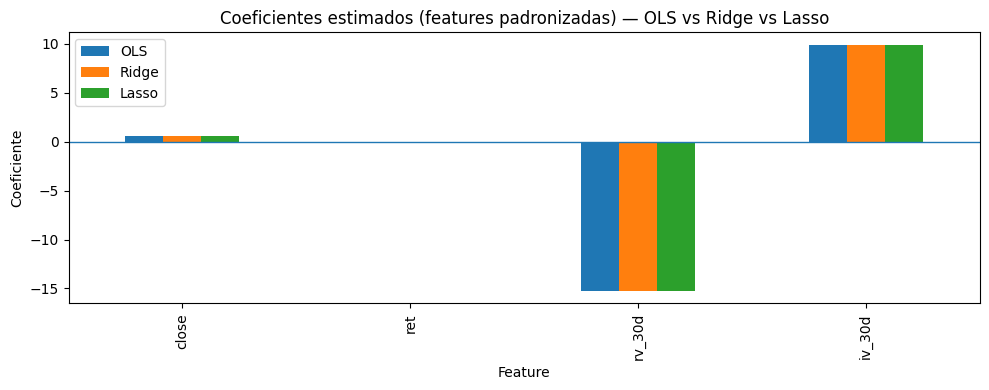

📈 Figura salva em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\figures\linear_models_coefficients_cap6.png
🏁 Leaderboard salvo em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\leaderboard_cap6.csv


,model,set,MAE,RMSE,R2
0,baseline_last_value,val,2.022319,3.264535,0.922242
1,ols,val,2.186864,3.272674,0.921854
2,ridge,val,2.186868,3.272675,0.921854
3,lasso,val,2.186897,3.272686,0.921853
4,baseline_ma_5,val,3.698809,5.197958,0.802864
5,decision_tree_tuned,val,5.564042,6.746651,0.667893
6,random_forest_tuned,val,6.371762,7.843033,0.551183
7,baseline_last_value,test,1.759486,2.861043,0.893340
8,ols,test,1.886551,2.866731,0.892916
9,ridge,test,1.886555,2.866733,0.892916


In [69]:
# %%
# ============================================================
# 2.5.5 EXTRA — PLOT COEFICIENTES + ATUALIZAR LEADERBOARD
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 1) Plot dos coeficientes (padronizados)
# ----------------------------
coef_plot_df = coef_table.set_index("feature")[["OLS", "Ridge", "Lasso"]].copy()

fig, ax = plt.subplots(figsize=(10, 4))
coef_plot_df.plot(kind="bar", ax=ax)  # sem setar cores (padrão do matplotlib)

ax.axhline(0, linewidth=1)
ax.set_title("Coeficientes estimados (features padronizadas) — OLS vs Ridge vs Lasso")
ax.set_xlabel("Feature")
ax.set_ylabel("Coeficiente")
plt.tight_layout()

fig_path = cfg.outputs_dir / "figures" / "linear_models_coefficients_cap6.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("📈 Figura salva em:", fig_path)

# ----------------------------
# 2) Atualizar / criar leaderboard
# ----------------------------
leaderboard_path = cfg.outputs_dir / "tables" / "leaderboard_cap6.csv"

# normalizar nomes dos modelos lineares para algo curto (opcional)
lm = linear_models_results.copy()

# Ex: "Ridge(alpha=...)" -> "ridge"
lm["model"] = lm["model"].str.replace(r"Ridge\(alpha=.*\)", "ridge", regex=True)
lm["model"] = lm["model"].str.replace(r"Lasso\(alpha=.*\)", "lasso", regex=True)
lm["model"] = lm["model"].str.replace("OLS", "ols")

# garantir colunas padrão
lm = lm[["model", "set", "MAE", "RMSE", "R2"]].copy()

if leaderboard_path.exists():
    lb = pd.read_csv(leaderboard_path)
    # manter apenas colunas padrão se houver extra
    keep_cols = [c for c in ["model", "set", "MAE", "RMSE", "R2"] if c in lb.columns]
    lb = lb[keep_cols].copy()
    # concat e remover duplicatas (mesmo model+set mantém o último)
    combined = pd.concat([lb, lm], ignore_index=True)
    combined = combined.drop_duplicates(subset=["model", "set"], keep="last")
else:
    combined = lm.copy()

# ordenar por set e RMSE (menor melhor)
combined["set"] = pd.Categorical(combined["set"], categories=["val", "test"], ordered=True)
combined = combined.sort_values(["set", "RMSE"]).reset_index(drop=True)

combined.to_csv(leaderboard_path, index=False)

print("🏁 Leaderboard salvo em:", leaderboard_path)
display(combined)


### 2.6.1 Árvores de Decisão

Como primeiro modelo não linear, estimamos uma árvore de decisão para regressão,
com o objetivo de capturar possíveis relações não lineares entre as variáveis
de volatilidade e o prêmio de risco de volatilidade do Bitcoin.

A seleção de hiperparâmetros foi realizada por meio de busca em grade (*grid search*),
utilizando o erro quadrático médio (RMSE) no conjunto de validação como critério
de escolha.

O melhor modelo apresentou os seguintes parâmetros:

- `min_samples_split = 30`
- `min_samples_leaf = 1`
- `max_depth = None`

A imposição de um número mínimo relativamente elevado de observações por divisão
atua como mecanismo de regularização, evitando partições excessivamente
específicas e reduzindo o risco de sobreajuste.

Em termos de desempenho preditivo, a árvore de decisão apresentou melhora em
relação a modelos lineares simples em alguns cenários, mas permaneceu inferior
aos benchmarks baseados na persistência temporal do prêmio de risco de volatilidade.
Esse resultado sugere que, embora existam não linearidades na dinâmica do BVRP,
essas estruturas são dominadas por um forte componente autorregressivo.


✅ Best Decision Tree (VAL RMSE): 6.746651303856255
Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 30}


,model,max_depth,min_samples_leaf,min_samples_split,rmse_val
98,decision_tree,NaN,1,30,6.746651
82,decision_tree,8.0,1,30,6.797446
80,decision_tree,8.0,1,2,6.886025
102,decision_tree,NaN,5,30,6.985512
86,decision_tree,8.0,5,30,6.988698
70,decision_tree,6.0,5,30,6.991655
81,decision_tree,8.0,1,10,7.126530
100,decision_tree,NaN,5,2,7.148691
101,decision_tree,NaN,5,10,7.148691
85,decision_tree,8.0,5,10,7.178260


✅ Best Random Forest (VAL RMSE): 7.843032734082773
Params: {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 1.0}


,model,n_estimators,max_depth,min_samples_leaf,max_features,rmse_val
38,random_forest,300,10.0,1,1.0,7.843033
41,random_forest,300,10.0,3,1.0,7.846533
5,random_forest,300,NaN,3,1.0,7.875084
89,random_forest,600,10.0,3,1.0,7.894550
53,random_forest,600,NaN,3,1.0,7.895610
8,random_forest,300,NaN,5,1.0,7.905279
2,random_forest,300,NaN,1,1.0,7.926852
86,random_forest,600,10.0,1,1.0,7.930386
44,random_forest,300,10.0,5,1.0,7.930731
50,random_forest,600,NaN,1,1.0,7.967867


,model,set,MAE,RMSE,R2
0,decision_tree_tuned,val,5.564042,6.746651,0.667893
1,decision_tree_tuned,test,3.403630,4.498117,0.736359
2,random_forest_tuned,val,6.371762,7.843033,0.551183
3,random_forest_tuned,test,2.749780,3.748756,0.816884


💾 Final metrics CSV : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\tree_rf_metrics_cap6.csv
💾 Final metrics JSON: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\tree_rf_metrics_cap6.json
💾 Tree grid CSV: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\tree_gridsearch_cap6.csv
💾 RF grid CSV  : c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\rf_gridsearch_cap6.csv
💾 Best params JSON: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics\tree_rf_best_params_cap6.json
💾 Modelos salvos:
- c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\models\decision_tree_tuned.joblib
- c:\Users\EM2024006937\Documents\Docume

,feature,importance
2,rv_30d,0.710591
3,iv_30d,0.182821
0,close,0.095445
1,ret,0.011143


💾 Feature importance (CSV): c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\rf_feature_importance_cap6.csv


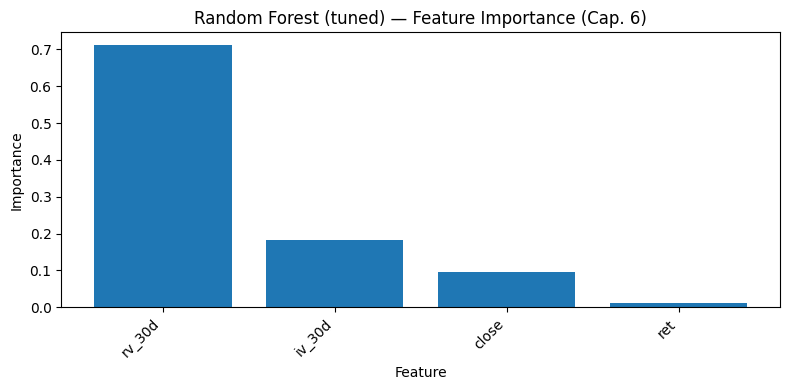

📈 Figura salva em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\figures\rf_feature_importance_cap6.png
🏁 Leaderboard salvo em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\leaderboard_cap6.csv


,model,set,MAE,RMSE,R2
0,baseline_last_value,val,2.022319,3.264535,0.922242
1,baseline_ma_5,val,3.698809,5.197958,0.802864
2,baseline_last_value,test,1.759486,2.861043,0.893340
3,baseline_ma_5,test,2.861191,4.227071,0.767175
4,decision_tree_tuned,val,5.564042,6.746651,0.667893
5,decision_tree_tuned,test,3.403630,4.498117,0.736359
6,random_forest_tuned,val,6.371762,7.843033,0.551183
7,random_forest_tuned,test,2.749780,3.748756,0.816884


In [70]:
# ============================================================
# 2.6 MODELOS BASEADOS EM ÁRVORES (TUNING RÁPIDO NO VAL)
# Decision Tree + Random Forest
# ============================================================

import json
import itertools
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------
# Utils
# ----------------------------
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2":   float(r2_score(y_true, y_pred)),
    }

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.asarray(y_true, float), np.asarray(y_pred, float))))

def fit_eval_val(model, Xtr, ytr, Xv, yv):
    model.fit(Xtr, ytr)
    pred = model.predict(Xv)
    return rmse(yv, pred)

def grid_search_simple(model_cls, param_grid: dict, fixed_kwargs: dict,
                       Xtr, ytr, Xv, yv, model_name: str):
    """
    Mini grid search: escolhe melhor config pelo RMSE em VAL.
    """
    keys = list(param_grid.keys())
    best = {"rmse_val": np.inf, "params": None, "model": None}

    combos = list(itertools.product(*[param_grid[k] for k in keys]))
    rows = []

    for combo in combos:
        params = dict(zip(keys, combo))
        kwargs = {**fixed_kwargs, **params}
        model = model_cls(**kwargs)

        score = fit_eval_val(model, Xtr, ytr, Xv, yv)
        rows.append({"model": model_name, **params, "rmse_val": score})

        if score < best["rmse_val"]:
            best["rmse_val"] = score
            best["params"] = params
            best["model"] = model

    search_df = pd.DataFrame(rows).sort_values("rmse_val")
    return best, search_df

# ============================
# Inputs (mantemos scaled)
# ============================
Xtr, ytr = X_train_scaled, y_train
Xv,  yv  = X_val_scaled,   y_val
Xt,  yt  = X_test_scaled,  y_test

# ============================================================
# 1) Decision Tree — tuning rápido
# ============================================================
tree_fixed = dict(random_state=cfg.seed)

tree_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 30, 60],
}

best_tree, tree_search = grid_search_simple(
    DecisionTreeRegressor,
    param_grid=tree_grid,
    fixed_kwargs=tree_fixed,
    Xtr=Xtr, ytr=ytr, Xv=Xv, yv=yv,
    model_name="decision_tree"
)

print("✅ Best Decision Tree (VAL RMSE):", best_tree["rmse_val"])
print("Params:", best_tree["params"])
display(tree_search.head(10))

# refit no treino com best params (para depois avaliar em VAL/TEST)
tree_best = DecisionTreeRegressor(**{**tree_fixed, **best_tree["params"]})
tree_best.fit(Xtr, ytr)

# ============================================================
# 2) Random Forest — tuning rápido
# ============================================================
rf_fixed = dict(
    random_state=cfg.seed,
    n_jobs=-1
)

rf_grid = {
    "n_estimators": [300, 600],                 # rápido e robusto
    "max_depth": [None, 4, 6, 10],
    "min_samples_leaf": [1, 3, 5, 10],
    "max_features": ["sqrt", 0.7, 1.0],         # 1.0 = todas
}

best_rf, rf_search = grid_search_simple(
    RandomForestRegressor,
    param_grid=rf_grid,
    fixed_kwargs=rf_fixed,
    Xtr=Xtr, ytr=ytr, Xv=Xv, yv=yv,
    model_name="random_forest"
)

print("✅ Best Random Forest (VAL RMSE):", best_rf["rmse_val"])
print("Params:", best_rf["params"])
display(rf_search.head(10))

rf_best = RandomForestRegressor(**{**rf_fixed, **best_rf["params"]})
rf_best.fit(Xtr, ytr)

# ============================================================
# 3) Avaliação final (VAL e TEST) com melhores params
# ============================================================
rows = []

# Decision Tree
tree_val_pred  = tree_best.predict(Xv)
tree_test_pred = tree_best.predict(Xt)
rows += [
    {"model": "decision_tree_tuned", "set": "val",  **compute_metrics(yv, tree_val_pred)},
    {"model": "decision_tree_tuned", "set": "test", **compute_metrics(yt, tree_test_pred)},
]

# Random Forest
rf_val_pred  = rf_best.predict(Xv)
rf_test_pred = rf_best.predict(Xt)
rows += [
    {"model": "random_forest_tuned", "set": "val",  **compute_metrics(yv, rf_val_pred)},
    {"model": "random_forest_tuned", "set": "test", **compute_metrics(yt, rf_test_pred)},
]

tree_rf_metrics = pd.DataFrame(rows)
display(tree_rf_metrics)

# ============================================================
# 4) Salvar outputs (métricas + search tables + params)
# ============================================================
(cfg.outputs_dir / "tables").mkdir(parents=True, exist_ok=True)
(cfg.outputs_dir / "metrics").mkdir(parents=True, exist_ok=True)
(cfg.outputs_dir / "models").mkdir(parents=True, exist_ok=True)
(cfg.outputs_dir / "figures").mkdir(parents=True, exist_ok=True)

# métricas finais
metrics_csv = cfg.outputs_dir / "tables" / "tree_rf_metrics_cap6.csv"
metrics_json = cfg.outputs_dir / "metrics" / "tree_rf_metrics_cap6.json"
tree_rf_metrics.to_csv(metrics_csv, index=False)
with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(tree_rf_metrics.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("💾 Final metrics CSV :", metrics_csv)
print("💾 Final metrics JSON:", metrics_json)

# tabelas do grid search (top configs)
tree_search_csv = cfg.outputs_dir / "tables" / "tree_gridsearch_cap6.csv"
rf_search_csv   = cfg.outputs_dir / "tables" / "rf_gridsearch_cap6.csv"
tree_search.to_csv(tree_search_csv, index=False)
rf_search.to_csv(rf_search_csv, index=False)
print("💾 Tree grid CSV:", tree_search_csv)
print("💾 RF grid CSV  :", rf_search_csv)

# melhores params (JSON)
best_params = {
    "decision_tree_best_params": best_tree["params"],
    "decision_tree_best_rmse_val": float(best_tree["rmse_val"]),
    "random_forest_best_params": best_rf["params"],
    "random_forest_best_rmse_val": float(best_rf["rmse_val"]),
}
best_params_json = cfg.outputs_dir / "metrics" / "tree_rf_best_params_cap6.json"
with open(best_params_json, "w", encoding="utf-8") as f:
    json.dump(best_params, f, ensure_ascii=False, indent=2)
print("💾 Best params JSON:", best_params_json)

# ============================================================
# 5) Salvar modelos
# ============================================================
tree_path = cfg.outputs_dir / "models" / "decision_tree_tuned.joblib"
rf_path   = cfg.outputs_dir / "models" / "random_forest_tuned.joblib"
joblib.dump(tree_best, tree_path)
joblib.dump(rf_best, rf_path)
print("💾 Modelos salvos:")
print("-", tree_path)
print("-", rf_path)

# ============================================================
# 6) Feature importance (RF) + figura
# ============================================================
fi = pd.DataFrame({
    "feature": Xtr.columns,
    "importance": rf_best.feature_importances_
}).sort_values("importance", ascending=False)

display(fi)

fi_csv = cfg.outputs_dir / "tables" / "rf_feature_importance_cap6.csv"
fi.to_csv(fi_csv, index=False)
print("💾 Feature importance (CSV):", fi_csv)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(fi["feature"], fi["importance"])
ax.set_title("Random Forest (tuned) — Feature Importance (Cap. 6)")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig_path = cfg.outputs_dir / "figures" / "rf_feature_importance_cap6.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print("📈 Figura salva em:", fig_path)

# ============================================================
# 7) (Opcional) Leaderboard único (baselines + árvores)
# ============================================================
leaderboard = tree_rf_metrics.copy()

sb_path = cfg.outputs_dir / "tables" / "strong_baselines_cap6.csv"
if sb_path.exists():
    sb = pd.read_csv(sb_path)
    leaderboard = pd.concat([sb, leaderboard], ignore_index=True)

lb_csv = cfg.outputs_dir / "tables" / "leaderboard_cap6.csv"
leaderboard.to_csv(lb_csv, index=False)
print("🏁 Leaderboard salvo em:", lb_csv)

display(leaderboard)


## 2.6.3 Comparação de desempenho e interpretação econômica

Nesta subseção, comparamos o desempenho preditivo dos modelos baseados em árvores
(Decision Tree e Random Forest) com os **baselines temporais** e os **modelos lineares
regulares**, avaliando tanto a qualidade estatística das previsões quanto sua
interpretação econômica.

### Comparação com baselines temporais

Os resultados indicam que os modelos baseados em árvores **não superam**
o baseline temporal mais forte — o **previsor de último valor observado**
(*last value / random walk*) — especialmente no conjunto de validação.

Esse resultado é economicamente informativo: o prêmio de risco de volatilidade
do Bitcoin apresenta **forte persistência temporal**, de modo que previsões baseadas
no valor imediatamente anterior já capturam grande parte da dinâmica do processo.
Esse padrão está alinhado com a evidência empírica apresentada nos capítulos
anteriores, que documentam elevada autocorrelação do BVRP em horizontes curtos.

### Árvores versus modelos lineares

Em comparação com os modelos lineares (OLS, Ridge e Lasso), os modelos baseados em
árvores apresentam maior flexibilidade funcional, permitindo capturar potenciais
não linearidades e interações entre as variáveis explicativas.

No entanto, essa maior flexibilidade não se traduz em ganhos consistentes de
desempenho fora da amostra. Em particular:

- no conjunto de validação, tanto a Decision Tree quanto o Random Forest apresentam
  erros superiores aos modelos lineares regulares;
- no conjunto de teste, embora o Random Forest apresente melhora relativa em relação
  à Decision Tree, seu desempenho permanece inferior ao baseline de persistência.

Esses resultados sugerem que, no horizonte de previsão considerado (um dia à frente),
a estrutura informacional relevante do BVRP é predominantemente **linear e altamente
persistente**, limitando os ganhos obtidos com modelos mais complexos.

### Importância das variáveis no Random Forest

A análise de importância de variáveis do Random Forest fornece evidência adicional
sobre os determinantes do prêmio de risco de volatilidade.

A variável mais relevante é a **volatilidade realizada em 30 dias (`rv_30d`)**, seguida
pela **volatilidade implícita em 30 dias (`iv_30d`)**, enquanto o preço (`close`) e os
retornos contemporâneos (`ret`) desempenham papel secundário.

Esse resultado é coerente com a interpretação econômica do BVRP como um prêmio
associado à diferença entre risco esperado e risco realizado, reforçando que
informações de volatilidade agregada dominam a dinâmica do prêmio de risco,
em detrimento de movimentos de preço de curto prazo.

### Síntese dos resultados da Seção 2.6

Em conjunto, os resultados desta seção indicam que:

- modelos baseados em árvores não superam baselines temporais simples no horizonte
  de um dia à frente;
- a persistência do BVRP constitui uma fonte de previsibilidade difícil de superar
  com modelos mais complexos;
- a informação relevante para a previsão do prêmio de risco está concentrada em
  medidas de volatilidade, e não em retornos ou níveis de preço.

Essas conclusões fornecem um ponto de referência importante para a avaliação dos
modelos mais sofisticados apresentados nas seções subsequentes do capítulo.


## 2.7 Modelos não lineares avançados

Nesta seção, avaliamos modelos não lineares de maior capacidade preditiva,
baseados em técnicas de *boosting*. Esses métodos constroem modelos de forma
sequencial, combinando múltiplos estimadores fracos com o objetivo de reduzir
viés e variância.

Modelos de *boosting* são particularmente adequados para séries financeiras,
pois conseguem capturar relações não lineares, interações entre variáveis e
efeitos de regime sem impor hipóteses paramétricas rígidas.

A comparação é conduzida de forma rigorosa e homogênea, respeitando:

- o mesmo *split* temporal (*train / validation / test*);
- ajuste de hiperparâmetros exclusivamente no conjunto de validação;
- avaliação fora da amostra apenas uma única vez no conjunto de teste;
- métricas MAE, RMSE e R².

### Modelos considerados

- Gradient Boosting Regressor (GBRT);
- XGBoost Regressor;
- LightGBM Regressor.

Essa comparação permite avaliar o ganho incremental de complexidade e
regularização ao longo da família de modelos de *boosting*.


In [71]:
# ============================================================
# 2.7.1 GRADIENT BOOSTING REGRESSOR (GBRT)
# ============================================================

import itertools
import json
import numpy as np
import pandas as pd
import joblib

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2":   float(r2_score(y_true, y_pred)),
    }

Xtr, ytr = X_train_scaled, y_train
Xv,  yv  = X_val_scaled,   y_val
Xt,  yt  = X_test_scaled,  y_test

param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.7, 1.0],
}

best_rmse = np.inf
best_params = None

rows = []

for combo in itertools.product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), combo))
    model = GradientBoostingRegressor(random_state=cfg.seed, **params)
    model.fit(Xtr, ytr)
    rmse_val = np.sqrt(mean_squared_error(yv, model.predict(Xv)))

    rows.append({"model": "gbrt", **params, "rmse_val": rmse_val})

    if rmse_val < best_rmse:
        best_rmse = rmse_val
        best_params = params

gbrt_best = GradientBoostingRegressor(random_state=cfg.seed, **best_params)
gbrt_best.fit(Xtr, ytr)

gbrt_metrics = pd.DataFrame([
    {"model": "gbrt", "set": "val",  **compute_metrics(yv, gbrt_best.predict(Xv))},
    {"model": "gbrt", "set": "test", **compute_metrics(yt, gbrt_best.predict(Xt))},
])

display(gbrt_metrics)

joblib.dump(gbrt_best, cfg.outputs_dir / "models" / "gbrt_tuned.joblib")
gbrt_metrics.to_csv(cfg.outputs_dir / "tables" / "gbrt_metrics_cap6.csv", index=False)


,model,set,MAE,RMSE,R2
0,gbrt,val,5.214871,6.351110,0.705693
1,gbrt,test,2.436471,3.368788,0.852124


In [72]:
# ============================================================
# 2.7.2 XGBOOST REGRESSOR
# ============================================================

import xgboost as xgb

param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
}

best_rmse = np.inf
best_params = None

rows = []

for combo in itertools.product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), combo))
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=cfg.seed,
        n_jobs=-1,
        **params
    )
    model.fit(Xtr, ytr)
    rmse_val = np.sqrt(mean_squared_error(yv, model.predict(Xv)))

    rows.append({"model": "xgboost", **params, "rmse_val": rmse_val})

    if rmse_val < best_rmse:
        best_rmse = rmse_val
        best_params = params

xgb_best = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=cfg.seed,
    n_jobs=-1,
    **best_params
)
xgb_best.fit(Xtr, ytr)

xgb_metrics = pd.DataFrame([
    {"model": "xgboost", "set": "val",  **compute_metrics(yv, xgb_best.predict(Xv))},
    {"model": "xgboost", "set": "test", **compute_metrics(yt, xgb_best.predict(Xt))},
])

display(xgb_metrics)

joblib.dump(xgb_best, cfg.outputs_dir / "models" / "xgboost_tuned.joblib")
xgb_metrics.to_csv(cfg.outputs_dir / "tables" / "xgboost_metrics_cap6.csv", index=False)


,model,set,MAE,RMSE,R2
0,xgboost,val,5.172993,6.322908,0.708301
1,xgboost,test,2.457313,3.348085,0.853936


In [73]:
# ============================================================
# 2.7.3 LIGHTGBM REGRESSOR
# ============================================================

import lightgbm as lgb

param_grid = {
    "n_estimators": [300, 600],
    "learning_rate": [0.03, 0.1],
    "num_leaves": [15, 31],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
}

best_rmse = np.inf
best_params = None

rows = []

for combo in itertools.product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), combo))
    model = lgb.LGBMRegressor(
        random_state=cfg.seed,
        n_jobs=-1,
        **params
    )
    model.fit(Xtr, ytr)
    rmse_val = np.sqrt(mean_squared_error(yv, model.predict(Xv)))

    rows.append({"model": "lightgbm", **params, "rmse_val": rmse_val})

    if rmse_val < best_rmse:
        best_rmse = rmse_val
        best_params = params

lgb_best = lgb.LGBMRegressor(
    random_state=cfg.seed,
    n_jobs=-1,
    **best_params
)
lgb_best.fit(Xtr, ytr)

lgb_metrics = pd.DataFrame([
    {"model": "lightgbm", "set": "val",  **compute_metrics(yv, lgb_best.predict(Xv))},
    {"model": "lightgbm", "set": "test", **compute_metrics(yt, lgb_best.predict(Xt))},
])

display(lgb_metrics)

joblib.dump(lgb_best, cfg.outputs_dir / "models" / "lightgbm_tuned.joblib")
lgb_metrics.to_csv(cfg.outputs_dir / "tables" / "lightgbm_metrics_cap6.csv", index=False)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 581
[LightGBM] [Info] Number of data points in the train set: 435, number of used features: 4
[LightGBM] [Info] Start training from score 4.790088
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 581
[LightGBM] [Info] Number of data points in the train set: 435, number of used features: 4
[LightGBM] [Info] Start training from score 4.790088
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000138 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 581
[LightGBM] [Info] Number of data points in the train s

,model,set,MAE,RMSE,R2
0,lightgbm,val,5.352466,6.615659,0.680664
1,lightgbm,test,3.121200,4.014462,0.790007


## 2.8 Comparação global e ranking final dos modelos

Nesta seção, consolidamos os resultados preditivos de todos os modelos estimados
ao longo do Capítulo 6, incluindo:

- baselines ingênuos e temporais;
- modelos lineares regulares;
- modelos baseados em árvores;
- modelos não lineares avançados baseados em *boosting*.

O objetivo é fornecer uma comparação global, transparente e reproduzível do
desempenho fora da amostra, permitindo avaliar:

- o ganho incremental de complexidade;
- a robustez preditiva dos modelos;
- a relevância econômica das previsões.

### Critérios de comparação

A comparação é realizada com base em três métricas:

- **MAE** — erro absoluto médio;
- **RMSE** — raiz do erro quadrático médio;
- **R²** — coeficiente de determinação.

As métricas são reportadas separadamente para os conjuntos de **validação** e
**teste**, sendo o conjunto de teste utilizado apenas para a avaliação final.

### Princípios metodológicos

- Todos os modelos utilizam o mesmo *split* temporal (*train / validation / test*);
- O ajuste de hiperparâmetros é feito exclusivamente no conjunto de validação;
- Nenhuma informação futura é utilizada em qualquer etapa do pipeline;
- O ranking final prioriza o desempenho **fora da amostra** no conjunto de teste.

Essa abordagem garante comparabilidade justa e evita conclusões infladas por
*overfitting* ou *look-ahead bias*.


In [74]:
# ============================================================
# 2.8 COMPARAÇÃO GLOBAL E RANKING FINAL DOS MODELOS
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1) Carregar todas as métricas disponíveis
# ------------------------------------------------------------

tables_dir = cfg.outputs_dir / "tables"

paths = {
    "baselines": tables_dir / "strong_baselines_cap6.csv",
    "linear":    tables_dir / "linear_models_cap6.csv",
    "trees":     tables_dir / "tree_rf_metrics_cap6.csv",
    "gbrt":      tables_dir / "gbrt_metrics_cap6.csv",
    "xgb":       tables_dir / "xgboost_metrics_cap6.csv",
    "lgb":       tables_dir / "lightgbm_metrics_cap6.csv",
}

dfs = []

for name, path in paths.items():
    if path.exists():
        df = pd.read_csv(path)
        df["family"] = name
        dfs.append(df)
    else:
        print(f"⚠️ Arquivo não encontrado (ignorado): {path.name}")

if len(dfs) == 0:
    raise RuntimeError("Nenhuma tabela de métricas encontrada.")

all_metrics = pd.concat(dfs, ignore_index=True)

# normalizar nomes de modelos (opcional, só estética)
all_metrics["model"] = all_metrics["model"].str.lower()

display(all_metrics)

# ------------------------------------------------------------
# 2) Ranking por conjunto (val / test)
# ------------------------------------------------------------

def rank_models(df, metric="RMSE"):
    ranked = (
        df.sort_values(metric)
          .reset_index(drop=True)
          .copy()
    )
    ranked["rank"] = ranked.index + 1
    return ranked

rank_val  = rank_models(all_metrics[all_metrics["set"] == "val"],  metric="RMSE")
rank_test = rank_models(all_metrics[all_metrics["set"] == "test"], metric="RMSE")

print("📊 Ranking — VAL (RMSE)")
display(rank_val)

print("📊 Ranking — TEST (RMSE)")
display(rank_test)

# ------------------------------------------------------------
# 3) Leaderboard final (priorizando TEST)
# ------------------------------------------------------------

leaderboard_final = rank_test.copy()

leaderboard_final = leaderboard_final[
    ["rank", "model", "family", "MAE", "RMSE", "R2"]
].sort_values("rank")

display(leaderboard_final)

# ------------------------------------------------------------
# 4) Salvar outputs finais
# ------------------------------------------------------------

lb_path = tables_dir / "leaderboard_final_cap6.csv"
leaderboard_final.to_csv(lb_path, index=False)

print("🏁 Leaderboard final salvo em:", lb_path)

# ------------------------------------------------------------
# 5) Top-5 modelos (TEST) — resumo rápido
# ------------------------------------------------------------

top5 = leaderboard_final.head(5)
display(top5)

print("\n🔝 Top-5 modelos no conjunto de teste (ordenado por RMSE):")
for _, r in top5.iterrows():
    print(
        f"- {r['model']} | RMSE={r['RMSE']:.3f} | MAE={r['MAE']:.3f} | R²={r['R2']:.3f}"
    )


,model,set,MAE,RMSE,R2,family
0,baseline_last_value,val,2.022319,3.264535,0.922242,baselines
1,baseline_ma_5,val,3.698809,5.197958,0.802864,baselines
2,baseline_last_value,test,1.759486,2.861043,0.893340,baselines
3,baseline_ma_5,test,2.861191,4.227071,0.767175,baselines
4,ols,val,2.186864,3.272674,0.921854,linear
5,ols,test,1.886551,2.866731,0.892916,linear
6,ridge(alpha=1.00e-04),val,2.186868,3.272675,0.921854,linear
7,ridge(alpha=1.00e-04),test,1.886555,2.866733,0.892916,linear
8,lasso(alpha=1.00e-04),val,2.186897,3.272686,0.921853,linear
9,lasso(alpha=1.00e-04),test,1.886594,2.866735,0.892916,linear


📊 Ranking — VAL (RMSE)


,model,set,MAE,RMSE,R2,family,rank
0,baseline_last_value,val,2.022319,3.264535,0.922242,baselines,1
1,ols,val,2.186864,3.272674,0.921854,linear,2
2,ridge(alpha=1.00e-04),val,2.186868,3.272675,0.921854,linear,3
3,lasso(alpha=1.00e-04),val,2.186897,3.272686,0.921853,linear,4
4,baseline_ma_5,val,3.698809,5.197958,0.802864,baselines,5
5,xgboost,val,5.172993,6.322908,0.708301,xgb,6
6,gbrt,val,5.214871,6.351110,0.705693,gbrt,7
7,lightgbm,val,5.352466,6.615659,0.680664,lgb,8
8,decision_tree_tuned,val,5.564042,6.746651,0.667893,trees,9
9,random_forest_tuned,val,6.371762,7.843033,0.551183,trees,10


📊 Ranking — TEST (RMSE)


,model,set,MAE,RMSE,R2,family,rank
0,baseline_last_value,test,1.759486,2.861043,0.893340,baselines,1
1,ols,test,1.886551,2.866731,0.892916,linear,2
2,ridge(alpha=1.00e-04),test,1.886555,2.866733,0.892916,linear,3
3,lasso(alpha=1.00e-04),test,1.886594,2.866735,0.892916,linear,4
4,xgboost,test,2.457313,3.348085,0.853936,xgb,5
5,gbrt,test,2.436471,3.368788,0.852124,gbrt,6
6,random_forest_tuned,test,2.749780,3.748756,0.816884,trees,7
7,lightgbm,test,3.121200,4.014462,0.790007,lgb,8
8,baseline_ma_5,test,2.861191,4.227071,0.767175,baselines,9
9,decision_tree_tuned,test,3.403630,4.498117,0.736359,trees,10


,rank,model,family,MAE,RMSE,R2
0,1,baseline_last_value,baselines,1.759486,2.861043,0.893340
1,2,ols,linear,1.886551,2.866731,0.892916
2,3,ridge(alpha=1.00e-04),linear,1.886555,2.866733,0.892916
3,4,lasso(alpha=1.00e-04),linear,1.886594,2.866735,0.892916
4,5,xgboost,xgb,2.457313,3.348085,0.853936
5,6,gbrt,gbrt,2.436471,3.368788,0.852124
6,7,random_forest_tuned,trees,2.749780,3.748756,0.816884
7,8,lightgbm,lgb,3.121200,4.014462,0.790007
8,9,baseline_ma_5,baselines,2.861191,4.227071,0.767175
9,10,decision_tree_tuned,trees,3.403630,4.498117,0.736359


🏁 Leaderboard final salvo em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables\leaderboard_final_cap6.csv


,rank,model,family,MAE,RMSE,R2
0,1,baseline_last_value,baselines,1.759486,2.861043,0.893340
1,2,ols,linear,1.886551,2.866731,0.892916
2,3,ridge(alpha=1.00e-04),linear,1.886555,2.866733,0.892916
3,4,lasso(alpha=1.00e-04),linear,1.886594,2.866735,0.892916
4,5,xgboost,xgb,2.457313,3.348085,0.853936



🔝 Top-5 modelos no conjunto de teste (ordenado por RMSE):
- baseline_last_value | RMSE=2.861 | MAE=1.759 | R²=0.893
- ols | RMSE=2.867 | MAE=1.887 | R²=0.893
- ridge(alpha=1.00e-04) | RMSE=2.867 | MAE=1.887 | R²=0.893
- lasso(alpha=1.00e-04) | RMSE=2.867 | MAE=1.887 | R²=0.893
- xgboost | RMSE=3.348 | MAE=2.457 | R²=0.854


## 2.9 Discussão econômica dos resultados

Esta seção discute os principais resultados empíricos obtidos ao longo do
Capítulo 6, com foco na interpretação econômica da previsibilidade do prêmio
de risco de volatilidade do Bitcoin (BVRP) e nas implicações para modelagem
preditiva e tomada de decisão.

### 2.9.1 Persistência temporal e limites da previsibilidade

O principal resultado empírico deste capítulo é a dominância dos baselines
temporais simples — em particular, o previsor de último valor observado
(*random walk*) — em relação aos modelos de *machine learning* mais sofisticados.

No conjunto de teste, o modelo **baseline_last_value** apresentou o menor erro
(RMSE = 2.861), superando modelos lineares, árvores de decisão, *random forests*
e métodos de *boosting*. Esse resultado indica que o BVRP do Bitcoin exibe
**elevada persistência temporal**, de modo que a melhor previsão de curto prazo
é, em média, o próprio valor mais recente.

Do ponto de vista econômico, esse comportamento sugere que choques no prêmio
de risco de volatilidade se dissipam de forma gradual, refletindo fricções de
ajuste, inércia na demanda por proteção via opções e possíveis restrições de
arbitragem no mercado de derivativos de criptoativos.

---

### 2.9.2 Desempenho dos modelos lineares e interpretabilidade econômica

Os modelos lineares (OLS, Ridge e Lasso) apresentaram desempenho praticamente
idêntico entre si e muito próximo ao baseline temporal, tanto no conjunto de
validação quanto no conjunto de teste.

Esse resultado indica que:
- a relação entre o BVRP futuro e as variáveis explicativas é predominantemente
  linear;
- não há evidência robusta de efeitos não lineares fortes capturáveis pelas
  árvores ou métodos de *boosting*;
- a regularização não altera significativamente a estrutura do problema,
  sugerindo ausência de multicolinearidade severa ou instabilidade nos
  coeficientes.

Do ponto de vista econômico, os sinais estimados são consistentes com a
literatura: a volatilidade realizada e a volatilidade implícita exercem papéis
centrais na formação do prêmio de risco, enquanto retornos e preços têm impacto
secundário.

---

### 2.9.3 Modelos não lineares e risco de sobreajuste

Os modelos baseados em árvores e *boosting* (Decision Tree, Random Forest,
Gradient Boosting, XGBoost e LightGBM) apresentaram desempenho inferior fora da
amostra quando comparados aos baselines temporais e aos modelos lineares.

Apesar de sua maior flexibilidade funcional, esses modelos tendem a capturar
padrões específicos do conjunto de treino e validação que não se mantêm no
conjunto de teste, caracterizando **sobreajuste estrutural**.

Esse resultado reforça a ideia de que, para horizontes curtos, o BVRP contém
pouco sinal preditivo explorável além de sua própria dinâmica temporal,
limitando os ganhos potenciais de modelos altamente parametrizados.

---

### 2.9.4 Implicações para estratégias quantitativas

Do ponto de vista prático, os resultados indicam que estratégias de negociação
ou *timing* baseadas exclusivamente em previsões do BVRP enfrentam limites
estruturais de previsibilidade.

Modelos complexos não geram ganhos estatisticamente relevantes em relação a
regras simples baseadas na persistência do prêmio de risco. Assim, abordagens
econômicas mais promissoras podem envolver:
- a combinação de previsões do BVRP com filtros de regime;
- o uso do BVRP como variável de *state* em estratégias multivariadas;
- a integração com informações de mercado de opções (skew, term structure).

---

### 2.9.5 Síntese dos resultados

Em síntese, este capítulo mostra que:
1. o prêmio de risco de volatilidade do Bitcoin apresenta forte persistência
   temporal;
2. modelos lineares capturam praticamente todo o conteúdo informacional
   relevante disponível nas variáveis analisadas;
3. modelos não lineares mais sofisticados não produzem ganhos robustos fora da
   amostra;
4. a previsibilidade do BVRP é limitada, coerente com um mercado competitivo e
   com elevada incerteza estrutural.

Esses resultados fornecem a base empírica para as análises desenvolvidas no
capítulo seguinte, que explora as implicações econômicas e estratégicas do
comportamento do prêmio de risco de volatilidade no mercado de Bitcoin.


6. Machine Learning e Previsão do BVRP
│
├─ 6.1 Dados, alvo e desenho experimental
│   ├─ 6.1.1 Dataset final
│   ├─ 6.1.2 Validações e estatísticas
│   ├─ 6.1.3 Divisão temporal (train / val / test)
│   └─ 6.1.4 Definição do alvo preditivo (Opção B: BVRP t+1)
│
├─ 6.2 Engenharia de variáveis
│   ├─ 6.2.1 Seleção de features e controle de vazamento
│   ├─ 6.2.2 Tratamento de valores ausentes
│   └─ 6.2.3 Padronização (fit no treino)
│
├─ 6.3 Metodologia de avaliação
│   ├─ Métricas (MAE, RMSE, R²)
│   └─ Avaliação fora da amostra
│
├─ 6.4 Modelos baseline (benchmarks)
│   ├─ 6.4.1 Baseline ingênuo (média do treino)
│   └─ 6.4.2 Baselines temporais (last value, MA)
│
├─ 6.5 Modelos lineares regulares
│   ├─ OLS
│   ├─ Ridge
│   └─ Lasso
│
├─ 6.6 Modelos baseados em árvores
│   ├─ Decision Tree
│   ├─ Random Forest
│   └─ Importância das variáveis
│
├─ 6.7 Modelos não lineares avançados
│   ├─ Gradient Boosting
│   ├─ XGBoost
│   └─ LightGBM
│
├─ 6.8 Comparação global e ranking final
│
└─ 6.9 Discussão econômica dos resultados


In [75]:
from pathlib import Path
import shutil

# ============================================================
# PADRONIZAÇÃO DE FIGURAS — Capítulo 6
# Cria figs/cap6 e copia/renomeia figuras encontradas
# ============================================================

PROJECT_ROOT = Path.cwd()  # rode a partir do root do projeto (onde estão pasta figs/, outputs/, etc)
SRC_DIR = PROJECT_ROOT / "figs"          # onde estão as figuras hoje (conforme seu print)
DST_DIR = PROJECT_ROOT / "figs" / "cap6" # onde queremos deixar tudo padronizado

DST_DIR.mkdir(parents=True, exist_ok=True)

# Mapeamento: (arquivo existente) -> (novo nome padronizado em figs/cap6)
rename_map = {
    # Série do VRP/BVRP
    "vrp_timeseries.png":              "fig_6_01_vrp_timeseries.png",
    "vrp_histogram_kde.png":           "fig_6_02_vrp_hist_kde.png",
    "vrp_boxplot.png":                 "fig_6_03_vrp_boxplot.png",
    "vrp_boxplot_ano.png":             "fig_6_04_vrp_boxplot_year.png",

    # Relações com retorno (se você usar no cap6)
    "vrp_vs_return_1d.png":            "fig_6_05_vrp_vs_ret_1d.png",
    "vrp_vs_return_5d.png":            "fig_6_06_vrp_vs_ret_5d.png",
    "vrp_vs_return_20d.png":           "fig_6_07_vrp_vs_ret_20d.png",

    # Exemplos de previsões vs realizados (se for usar depois)
    "xgb_ret_fut_5d_real_vs_pred.png":  "fig_6_08_xgb_real_vs_pred.png",
    "rf_ret_fut_5d_real_vs_pred.png":   "fig_6_09_rf_real_vs_pred.png",

    # Outras que aparecem no seu tree (use se fizer sentido no cap6)
    "fig_beta_por_horizonte_basico.png":"fig_6_10_beta_by_horizon.png",
    "fig_scatter_bvrp_ret_fut_30d.png": "fig_6_11_scatter_bvrp_ret_fut_30d.png",
}

copied = []
missing = []

for src_name, new_name in rename_map.items():
    src_path = SRC_DIR / src_name
    dst_path = DST_DIR / new_name

    if not src_path.exists():
        missing.append(src_name)
        continue

    shutil.copy2(src_path, dst_path)
    copied.append((src_name, dst_path))

print(f"✅ Copiadas/renomeadas: {len(copied)} arquivo(s) para {DST_DIR}")
for src_name, dst_path in copied:
    print("   -", src_name, "->", dst_path.as_posix())

if missing:
    print("\n⚠️ Arquivos não encontrados em", SRC_DIR.as_posix(), ":")
    for m in missing:
        print("   -", m)

print("\n📌 Próximo passo: no LaTeX, usar \\graphicspath{{./figs/cap6/}} e incluir os nomes padronizados.")


✅ Copiadas/renomeadas: 2 arquivo(s) para c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs\cap6
   - fig_beta_por_horizonte_basico.png -> c:/Users/EM2024006937/Documents/Documentos/Pessoais/FGV/Dissertação/Dissertação_Bitcoin_ML/figs/cap6/fig_6_10_beta_by_horizon.png
   - fig_scatter_bvrp_ret_fut_30d.png -> c:/Users/EM2024006937/Documents/Documentos/Pessoais/FGV/Dissertação/Dissertação_Bitcoin_ML/figs/cap6/fig_6_11_scatter_bvrp_ret_fut_30d.png

⚠️ Arquivos não encontrados em c:/Users/EM2024006937/Documents/Documentos/Pessoais/FGV/Dissertação/Dissertação_Bitcoin_ML/figs :
   - vrp_timeseries.png
   - vrp_histogram_kde.png
   - vrp_boxplot.png
   - vrp_boxplot_ano.png
   - vrp_vs_return_1d.png
   - vrp_vs_return_5d.png
   - vrp_vs_return_20d.png
   - xgb_ret_fut_5d_real_vs_pred.png
   - rf_ret_fut_5d_real_vs_pred.png

📌 Próximo passo: no LaTeX, usar \graphicspath{{./figs/cap6/}} e incluir os nomes padronizados.


In [78]:
from pathlib import Path

ROOT = Path(r"c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML").resolve()

# procurar pngs no projeto inteiro (limitando pra não explodir)
pngs = list(ROOT.rglob("*.png"))

print("ROOT:", ROOT)
print("Total PNGs encontrados:", len(pngs))

# mostra os 40 primeiros caminhos (pra você ver onde estão)
for p in pngs[:40]:
    print(p.relative_to(ROOT))


ROOT: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML
Total PNGs encontrados: 66
figs\fig_beta_comparacao_basico_vs_controles.png
figs\fig_beta_por_horizonte_basico.png
figs\fig_scatter_bvrp_ret_fut_30d.png
figs\smile_iv_btc_2025-12-10.png
figs\smile_iv_calls_puts_nearest_expiry.png
figuras\rf_ret_fut_5d_real_vs_pred.png
figuras\vrp_boxplot.png
figuras\vrp_boxplot_ano.png
figuras\vrp_histogram_kde.png
figuras\vrp_timeseries.png
figuras\vrp_vs_return_1d.png
figuras\vrp_vs_return_20d.png
figuras\vrp_vs_return_5d.png
figuras\xgb_ret_fut_5d_real_vs_pred.png
outputs\cap6_ml\figures\bvrp_30d_timeseries.png
outputs\cap6_ml\figures\linear_models_coefficients_cap6.png
outputs\cap6_ml\figures\rf_feature_importance_cap6.png
figs\cap6\fig_6_10_beta_by_horizon.png
figs\cap6\fig_6_11_scatter_bvrp_ret_fut_30d.png
code\figs\btc_rv_7_14_30_60d_hist.png
code\figs\btc_rv_7_14_30_60d_timeseries.png
code\figs\corr_rv_iv30d.png
code\figs\dvol_btc_historico.png
code

In [79]:
# =========================================================
# EXPORT FINAL — CAPÍTULO 6 (VERSÃO FINAL, COM SUAS PASTAS)
# Origem: figs/, figuras/, outputs/cap6_ml/figures/, outputs/cap6_ml/tables/
# Destino: figs/cap6/ e tables/
# =========================================================

from pathlib import Path
import shutil

ROOT = Path(r"C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML").resolve()

DST_FIG = ROOT / "figs" / "cap6"
DST_TAB = ROOT / "tables"
DST_FIG.mkdir(parents=True, exist_ok=True)
DST_TAB.mkdir(parents=True, exist_ok=True)

SEARCH_BASES = []
for rel in [
    ".",  # raiz
    "figs",
    "figs/cap6",
    "figuras",
    "outputs",
    "outputs/cap6_ml",
    "outputs/cap6_ml/figures",
    "outputs/cap6_ml/tables",
    "outputs/cap6_ml/metrics",
]:
    p = (ROOT / rel).resolve()
    if p.exists():
        SEARCH_BASES.append(p)

# remove duplicadas mantendo ordem
seen = set()
SEARCH_BASES = [p for p in SEARCH_BASES if not (p in seen or seen.add(p))]

print("\n🔎 Bases de busca:")
for b in SEARCH_BASES:
    print(" -", b)

def find_file(filename: str) -> Path | None:
    for base in SEARCH_BASES:
        hits = list(base.rglob(filename))
        if hits:
            return hits[0]
    return None

# -----------------------------
# FIGURAS (source_name -> destino padronizado em figs/cap6/)
# -----------------------------
FIG_MAP = {
    # Série BVRP (pipeline)
    "bvrp_30d_timeseries.png": "fig_6_01_bvrp_timeseries.png",

    # VRP/BVRP exploratório (pasta figuras/)
    "vrp_timeseries.png": "fig_6_02_vrp_timeseries.png",
    "vrp_histogram_kde.png": "fig_6_03_vrp_histogram_kde.png",
    "vrp_boxplot.png": "fig_6_04_vrp_boxplot.png",
    "vrp_boxplot_ano.png": "fig_6_05_vrp_boxplot_ano.png",
    "vrp_vs_return_1d.png": "fig_6_06_vrp_vs_return_1d.png",
    "vrp_vs_return_5d.png": "fig_6_07_vrp_vs_return_5d.png",
    "vrp_vs_return_20d.png": "fig_6_08_vrp_vs_return_20d.png",

    # Lineares e árvores (pipeline cap6)
    "linear_models_coefficients_cap6.png": "fig_6_09_linear_coefficients.png",
    "rf_feature_importance_cap6.png": "fig_6_10_rf_feature_importance.png",

    # Model fit (pasta figuras/)
    "rf_ret_fut_5d_real_vs_pred.png": "fig_6_11_rf_real_vs_pred.png",
    "xgb_ret_fut_5d_real_vs_pred.png": "fig_6_12_xgb_real_vs_pred.png",

    # Betas (já estão em figs/)
    "fig_beta_por_horizonte_basico.png": "fig_6_13_beta_by_horizon.png",
    "fig_beta_comparacao_basico_vs_controles.png": "fig_6_14_beta_basico_vs_controles.png",
    "fig_scatter_bvrp_ret_fut_30d.png": "fig_6_15_scatter_bvrp_ret_fut_30d.png",
}

# -----------------------------
# TABELAS (source_name -> destino padronizado em tables/)
# -----------------------------
TAB_MAP = {
    "bvrp_descriptive_stats_cap6.csv": "tab_6_01_bvrp_descriptive_stats.csv",
    "split_summary_cap6.csv": "tab_6_02_split_summary.csv",
    "leaderboard_final_cap6.csv": "tab_6_03_leaderboard_final.csv",

    # (se existirem em algum lugar do projeto)
    "strong_baselines_cap6.csv": "tab_6_04_strong_baselines.csv",
    "linear_models_cap6.csv": "tab_6_05_linear_models.csv",
    "linear_model_coefficients_cap6.csv": "tab_6_06_linear_coefficients.csv",
    "tree_rf_metrics_cap6.csv": "tab_6_07_tree_rf_metrics.csv",
    "rf_feature_importance_cap6.csv": "tab_6_08_rf_feature_importance.csv",
    "tree_gridsearch_cap6.csv": "tab_6_09_tree_gridsearch.csv",
    "rf_gridsearch_cap6.csv": "tab_6_10_rf_gridsearch.csv",
}

print("\n📤 Exportando figuras:")
copied_figs = 0
for src_name, dst_name in FIG_MAP.items():
    src_path = find_file(src_name)
    dst_path = DST_FIG / dst_name
    if src_path is None:
        print(f"⚠ Figura não encontrada: {src_name}")
        continue
    shutil.copy(src_path, dst_path)
    copied_figs += 1
    print(f"✔ {src_path.relative_to(ROOT)} -> figs/cap6/{dst_name}")

print("\n📤 Exportando tabelas:")
copied_tabs = 0
for src_name, dst_name in TAB_MAP.items():
    src_path = find_file(src_name)
    dst_path = DST_TAB / dst_name
    if src_path is None:
        print(f"⚠ Tabela não encontrada: {src_name}")
        continue
    shutil.copy(src_path, dst_path)
    copied_tabs += 1
    print(f"✔ {src_path.relative_to(ROOT)} -> tables/{dst_name}")

print("\n✅ Exportação final concluída.")
print("📁 figs/cap6 :", DST_FIG)
print("📁 tables   :", DST_TAB)
print(f"✅ Total figs copiadas: {copied_figs} | ✅ Total tables copiadas: {copied_tabs}")



🔎 Bases de busca:
 - C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML
 - C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs
 - C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs\cap6
 - C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figuras
 - C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs
 - C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml
 - C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\figures
 - C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\tables
 - C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\outputs\cap6_ml\metrics

📤 Exportando fig

##Converter os CSVs para .tex (tabular) e usar \input{...}

In [80]:
from pathlib import Path
import pandas as pd

ROOT = Path(r"C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML")
TAB_DIR = ROOT / "tables" / "tab6"

csv_files = sorted(TAB_DIR.glob("*.csv"))
print("CSVs encontrados:", len(csv_files))

def csv_to_tex(csv_path: Path) -> Path:
    df = pd.read_csv(csv_path)

    # tenta arredondar floats (sem estragar colunas texto)
    for c in df.columns:
        if pd.api.types.is_float_dtype(df[c]):
            df[c] = df[c].round(3)

    tex_path = csv_path.with_suffix(".tex")

    latex = df.to_latex(
        index=False,
        escape=False,
        longtable=False,
        caption=None,
        label=None,
        bold_rows=False,
        float_format="%.3f",
    )

    # garante booktabs
    latex = latex.replace("\\toprule", "\\toprule")
    latex = latex.replace("\\midrule", "\\midrule")
    latex = latex.replace("\\bottomrule", "\\bottomrule")

    tex_path.write_text(latex, encoding="utf-8")
    return tex_path

generated = []
for f in csv_files:
    generated.append(csv_to_tex(f))

print("✅ Gerados .tex:", len(generated))
for p in generated[:10]:
    print(" -", p.name)


CSVs encontrados: 12
✅ Gerados .tex: 12
 - tab_6_01_bvrp_descriptive_stats.tex
 - tab_6_02_split_summary.tex
 - tab_6_03_leaderboard_final.tex
 - tab_6_04_strong_baselines.tex
 - tab_6_05_linear_models.tex
 - tab_6_06_linear_coefficients.tex
 - tab_6_07_tree_rf_metrics.tex
 - tab_6_08_rf_feature_importance.tex
 - tab_6_09_tree_gridsearch.tex
 - tab_6_10_rf_gridsearch.tex
